# Mount


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Cell 1: Import semua library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
import os
import glob
import json

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler, RobustScaler

# Untuk Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [4]:
input_folder = '/content/drive/MyDrive/Dataset Skripsi /dataLabel'

# Combine Data


In [5]:
if not os.path.exists(input_folder):
    print(f"❌ Folder tidak ditemukan: {input_folder}")
    print("Pastikan path benar dan Drive sudah di-mount.")
else:
    # 4. Ambil semua file CSV
    all_files = glob.glob(os.path.join(input_folder, "*.csv"))
    print(f"✅ Ditemukan {len(all_files)} file CSV.")

    # 5. Baca dan gabungkan semua file
    df_list = []
    for file in all_files:
        temp_df = pd.read_csv(file)
        temp_df['source_file'] = os.path.basename(file)   # opsional: lacak asal file
        df_list.append(temp_df)

    df = pd.concat(df_list, ignore_index=True)
    print(f"📊 Total data setelah digabung: {df.shape[0]} baris x {df.shape[1]} kolom")

    # 6. Bersihkan kolom kosong (misal: kolom hasil koma ganda seperti ",,label")
    # Hapus kolom yang semua nilainya NaN
    df = df.dropna(axis=1, how='all')
    # Hapus kolom bernama 'Unnamed: ...' yang muncul dari koma berlebih
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    # 7. Urutkan berdasarkan timestamp (prioritas: epoch_ms -> ts_millis -> date+time)
    if 'epoch_ms' in df.columns:
        df = df.sort_values(by='epoch_ms').reset_index(drop=True)
        print("📈 Data diurutkan berdasarkan kolom 'epoch_ms'.")
    elif 'ts_millis' in df.columns:
        df = df.sort_values(by='ts_millis').reset_index(drop=True)
        print("📈 Data diurutkan berdasarkan kolom 'ts_millis'.")
    elif 'date' in df.columns and 'time' in df.columns:
        df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
        df = df.sort_values(by='datetime').reset_index(drop=True)
        print("📈 Data diurutkan berdasarkan gabungan 'date' + 'time'.")
    else:
        print("⚠️ Tidak ada kolom waktu yang dikenali. Data tidak diurutkan.")

    # 8. Tampilkan cuplikan hasil
    print("\n🔍 5 baris pertama setelah penggabungan & pengurutan:")
    display(df.head())

    # 9. Tampilkan informasi kolom
    print("\n📋 Tipe data setiap kolom:")
    print(df.dtypes)

✅ Ditemukan 21 file CSV.
📊 Total data setelah digabung: 14408 baris x 23 kolom
📈 Data diurutkan berdasarkan kolom 'epoch_ms'.

🔍 5 baris pertama setelah penggabungan & pengurutan:


,subject_id,nama,date,time,epoch_ms,ts_millis,ax1,ay1,az1,gx1,...,ax2,ay2,az2,gx2,gy2,gz2,pressure_hpa,altitude_m,label,source_file
0,2,anisa,5/20/2026,12:06:44 PM,1162343642,332186,1.02295,-0.06201,0.37354,1.641,...,0.91528,0.46069,0.21826,-2.855,-2.794,-3.985,1005.64,63.560,benar,02-anisa.csv
1,2,anisa,5/20/2026,12:06:44 PM,1162343842,332386,1.02295,-0.06201,0.37354,1.641,...,0.91528,0.46069,0.21826,-2.855,-2.794,-3.985,1005.63,63.641,benar,02-anisa.csv
2,2,anisa,5/20/2026,12:06:45 PM,1162344042,332586,1.02295,-0.06201,0.37354,1.641,...,0.91528,0.46069,0.21826,-2.855,-2.794,-3.985,1005.63,63.641,benar,02-anisa.csv
3,2,anisa,5/20/2026,12:06:45 PM,1162344251,332795,0.62793,-0.00537,0.97144,-1.550,...,0.95630,0.33252,0.16479,13.626,5.649,-8.069,1005.63,63.641,benar,02-anisa.csv
4,2,anisa,5/20/2026,12:06:45 PM,1162344442,331986,0.62793,-0.00537,0.97144,-1.550,...,0.95630,0.33252,0.16479,13.626,5.649,-8.069,1005.64,63.560,benar,02-anisa.csv



📋 Tipe data setiap kolom:
subject_id        int64
nama             object
date             object
time             object
epoch_ms          int64
ts_millis         int64
ax1             float64
ay1             float64
az1             float64
gx1             float64
gy1             float64
gz1             float64
ax2             float64
ay2             float64
az2             float64
gx2             float64
gy2             float64
gz2             float64
pressure_hpa    float64
altitude_m      float64
label            object
source_file      object
dtype: object


In [6]:
print("\n==================================================")
print("1. INFORMASI UMUM DATASET")
print("==================================================")
df.info()

print("\n==================================================")
print("2. STATISTIK DESKRIPTIF (SEMUA KOLOM)")
print("==================================================")
display(df.describe(include='all'))


1. INFORMASI UMUM DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14408 entries, 0 to 14407
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   subject_id    14408 non-null  int64  
 1   nama          14408 non-null  object 
 2   date          14408 non-null  object 
 3   time          14408 non-null  object 
 4   epoch_ms      14408 non-null  int64  
 5   ts_millis     14408 non-null  int64  
 6   ax1           14408 non-null  float64
 7   ay1           14404 non-null  float64
 8   az1           14405 non-null  float64
 9   gx1           14402 non-null  float64
 10  gy1           14405 non-null  float64
 11  gz1           14402 non-null  float64
 12  ax2           14404 non-null  float64
 13  ay2           14397 non-null  float64
 14  az2           14400 non-null  float64
 15  gx2           14401 non-null  float64
 16  gy2           14401 non-null  float64
 17  gz2           14400 non-null  float64
 18 

,subject_id,nama,date,time,epoch_ms,ts_millis,ax1,ay1,az1,gx1,...,ax2,ay2,az2,gx2,gy2,gz2,pressure_hpa,altitude_m,label,source_file
count,14408.000000,14408,14408,14408,1.440800e+04,1.440800e+04,14408.000000,14404.000000,14405.000000,14402.000000,...,14404.000000,14397.000000,14400.000000,14401.000000,14401.000000,14400.000000,14379.000000,14379.000000,12878,14408
unique,NaN,21,5,2630,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,21
top,NaN,sutri,6/1/2026,3:26:29 PM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,benar,13-sutri.csv
freq,NaN,1500,5350,20,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4852,1500
mean,12.793101,NaN,NaN,NaN,1.720210e+09,3.755611e+05,0.660226,0.002006,0.593013,-0.237127,...,0.817968,0.115369,0.466731,-1.005165,-0.224377,0.995364,1005.531159,64.469548,NaN,NaN
std,6.313858,NaN,NaN,NaN,4.563549e+08,2.925755e+05,0.484347,0.148302,0.338672,20.754756,...,0.353297,0.267549,0.446097,29.355216,44.698161,17.968122,1.262612,10.582971,NaN,NaN
min,1.000000,NaN,NaN,NaN,1.162344e+09,7.700000e+03,-1.168460,-1.093510,-0.927250,-180.687000,...,-0.603270,-1.419430,-0.847410,-250.137000,-250.137000,-172.458000,1002.550000,52.042000,NaN,NaN
25%,7.000000,NaN,NaN,NaN,1.351196e+09,1.370440e+05,0.467407,-0.078610,0.350340,-8.000000,...,0.699400,-0.075930,0.127440,-10.802000,-14.672000,-4.771000,1005.330000,56.612000,NaN,NaN
50%,13.000000,NaN,NaN,NaN,1.436089e+09,2.566915e+05,0.841060,0.019290,0.580570,-0.489000,...,0.907710,0.068360,0.441160,-1.000000,0.550000,1.015000,1005.710000,62.928000,NaN,NaN
75%,18.000000,NaN,NaN,NaN,2.211127e+09,7.066438e+05,0.995850,0.090580,0.835940,6.746000,...,1.004880,0.293950,0.804750,9.374000,13.298000,6.527000,1006.470000,66.121000,NaN,NaN


 # EDA

In [7]:
# Cell EDA 1: Informasi umum dataset
print("="*50)
print("1. INFORMASI UMUM DATASET")
print("="*50)
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print("\nNama kolom:")
print(df.columns.tolist())

print("\n" + "="*50)
print("2. STATISTIK DESKRIPTIF (KOLOM NUMERIK)")
print("="*50)
display(df.describe())

print("\n" + "="*50)
print("3. STATISTIK KOLOM KATEGORIK")
print("="*50)
display(df.describe(include=['object']))

1. INFORMASI UMUM DATASET
Jumlah baris: 14408
Jumlah kolom: 22

Nama kolom:
['subject_id', 'nama', 'date', 'time', 'epoch_ms', 'ts_millis', 'ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'pressure_hpa', 'altitude_m', 'label', 'source_file']

2. STATISTIK DESKRIPTIF (KOLOM NUMERIK)


,subject_id,epoch_ms,ts_millis,ax1,ay1,az1,gx1,gy1,gz1,ax2,ay2,az2,gx2,gy2,gz2,pressure_hpa,altitude_m
count,14408.000000,1.440800e+04,1.440800e+04,14408.000000,14404.000000,14405.000000,14402.000000,14405.000000,14402.000000,14404.000000,14397.000000,14400.000000,14401.000000,14401.000000,14400.000000,14379.000000,14379.000000
mean,12.793101,1.720210e+09,3.755611e+05,0.660226,0.002006,0.593013,-0.237127,-1.066642,-0.624235,0.817968,0.115369,0.466731,-1.005165,-0.224377,0.995364,1005.531159,64.469548
std,6.313858,4.563549e+08,2.925755e+05,0.484347,0.148302,0.338672,20.754756,48.220046,12.243127,0.353297,0.267549,0.446097,29.355216,44.698161,17.968122,1.262612,10.582971
min,1.000000,1.162344e+09,7.700000e+03,-1.168460,-1.093510,-0.927250,-180.687000,-222.847000,-103.153000,-0.603270,-1.419430,-0.847410,-250.137000,-250.137000,-172.458000,1002.550000,52.042000
25%,7.000000,1.351196e+09,1.370440e+05,0.467407,-0.078610,0.350340,-8.000000,-15.206000,-4.679000,0.699400,-0.075930,0.127440,-10.802000,-14.672000,-4.771000,1005.330000,56.612000
50%,13.000000,1.436089e+09,2.566915e+05,0.841060,0.019290,0.580570,-0.489000,0.916000,-0.504000,0.907710,0.068360,0.441160,-1.000000,0.550000,1.015000,1005.710000,62.928000
75%,18.000000,2.211127e+09,7.066438e+05,0.995850,0.090580,0.835940,6.746000,13.824000,3.641000,1.004880,0.293950,0.804750,9.374000,13.298000,6.527000,1006.470000,66.121000
max,24.000000,2.301807e+09,1.343424e+06,1.999940,0.670900,1.999940,197.885000,250.130000,154.901000,1.999940,1.961910,1.999940,249.511000,250.031000,184.244000,1007.010000,89.467000



3. STATISTIK KOLOM KATEGORIK


,nama,date,time,label,source_file
count,14408,14408,14408,12878,14408
unique,21,5,2630,4,21
top,sutri,6/1/2026,3:26:29 PM,benar,13-sutri.csv
freq,1500,5350,20,4852,1500


## Missing Values

MISSING VALUES PER KOLOM


,Missing Values,Persentase (%)
label,1530,10.619100
pressure_hpa,29,0.201277
altitude_m,29,0.201277
ay2,11,0.076346
gz2,8,0.055525
az2,8,0.055525
gx2,7,0.048584
gy2,7,0.048584
gx1,6,0.041644
gz1,6,0.041644



⚠️ Ada missing values. Perlu ditangani pada tahap cleaning.


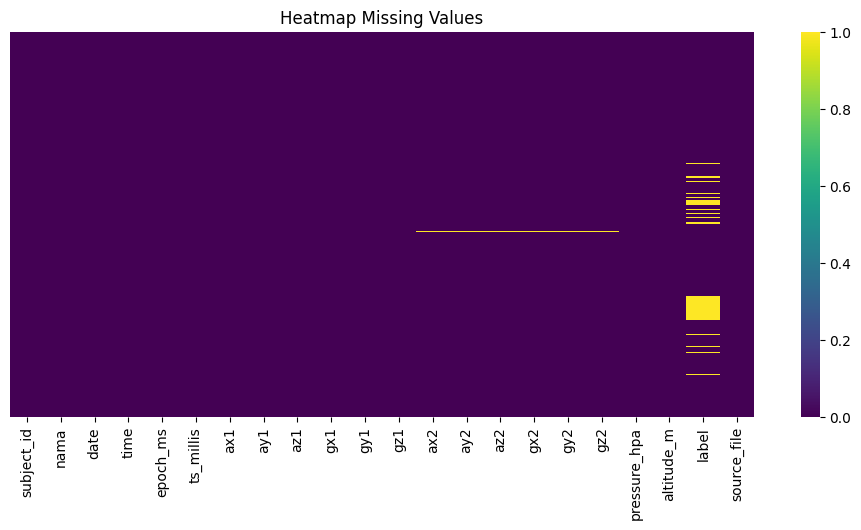

In [8]:
# Cell EDA 2: Analisis missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Persentase (%)': missing_percent
}).sort_values(by='Persentase (%)', ascending=False)

print("="*50)
print("MISSING VALUES PER KOLOM")
print("="*50)
display(missing_table[missing_table['Missing Values'] > 0])

if missing_table['Missing Values'].sum() == 0:
    print("\n✅ Tidak ada missing values dalam dataset.")
else:
    print("\n⚠️ Ada missing values. Perlu ditangani pada tahap cleaning.")

# Visualisasi missing values heatmap (jika ada)
if missing_table['Missing Values'].sum() > 0:
    plt.figure(figsize=(12, 5))
    sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
    plt.title('Heatmap Missing Values')
    plt.show()

## Distribusi dan Outlier

Kolom numerik yang ditemukan: ['subject_id', 'epoch_ms', 'ts_millis', 'ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'pressure_hpa', 'altitude_m']


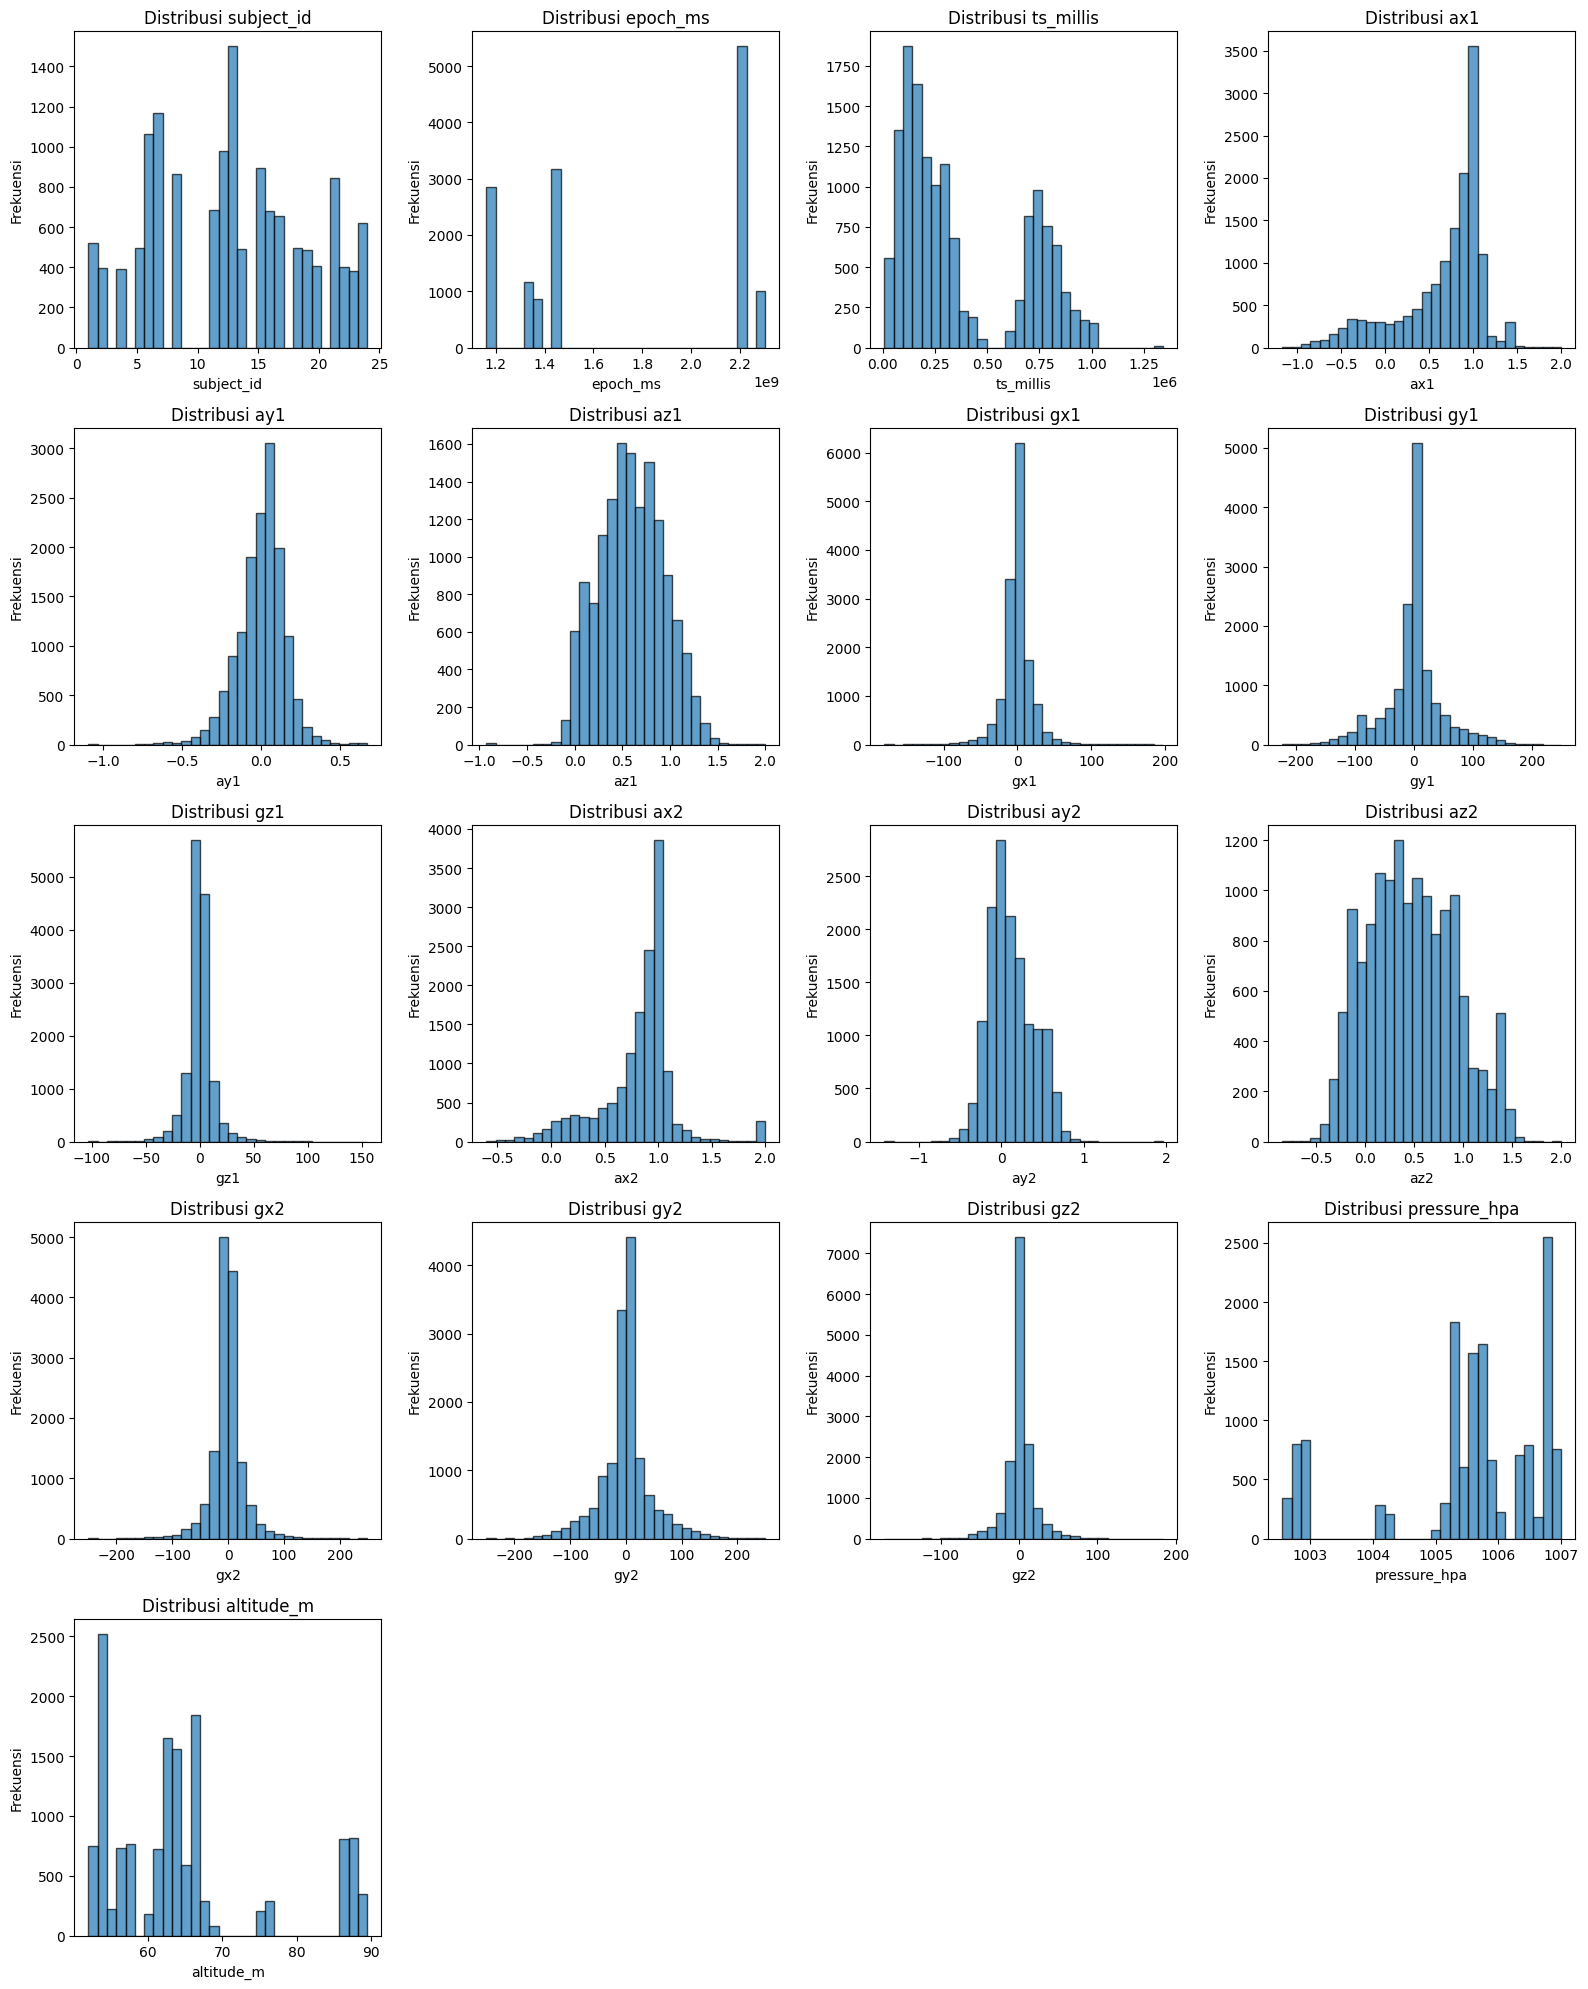

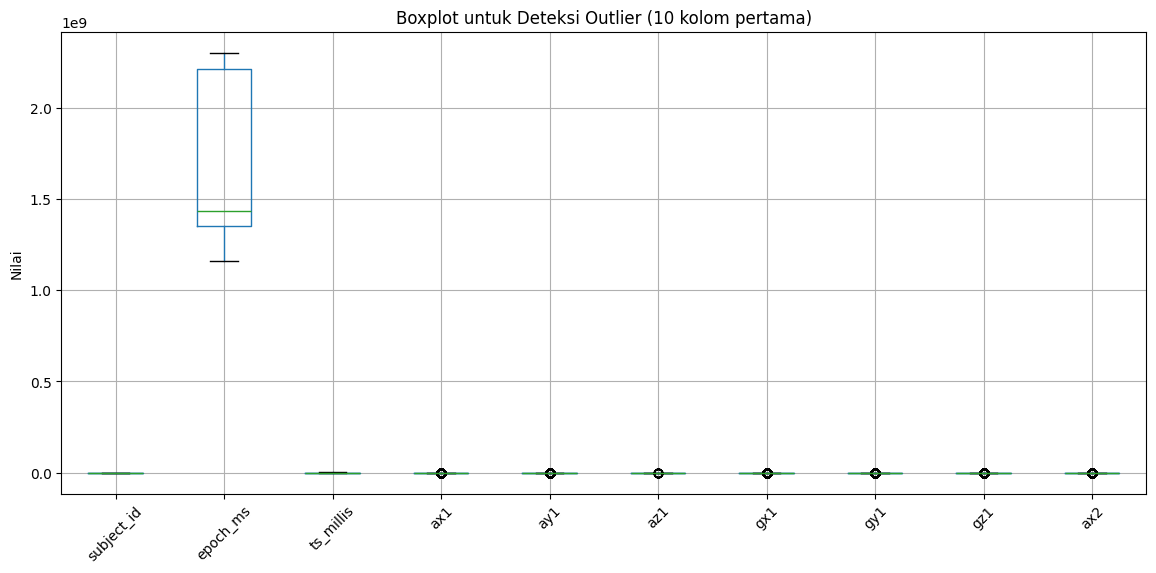

In [9]:
# Cell EDA 3: Distribusi dan outlier pada kolom numerik
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Kolom numerik yang ditemukan:", num_cols)

if len(num_cols) > 0:
    # Histogram untuk semua kolom numerik
    n_cols = len(num_cols)
    n_rows = (n_cols + 3) // 4  # atur layout 4 kolom per baris
    fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols > 0 else []

    for i, col in enumerate(num_cols):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Distribusi {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frekuensi')

    # Hapus subplot kosong
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    # Boxplot untuk deteksi outlier (maksimal 10 kolom)
    cols_to_plot = num_cols[:10] if len(num_cols) > 10 else num_cols
    plt.figure(figsize=(14, 6))
    df[cols_to_plot].boxplot(rot=45)
    plt.title('Boxplot untuk Deteksi Outlier (10 kolom pertama)')
    plt.ylabel('Nilai')
    plt.show()
else:
    print("Tidak ada kolom numerik.")

## Korelasi Antar Fitur

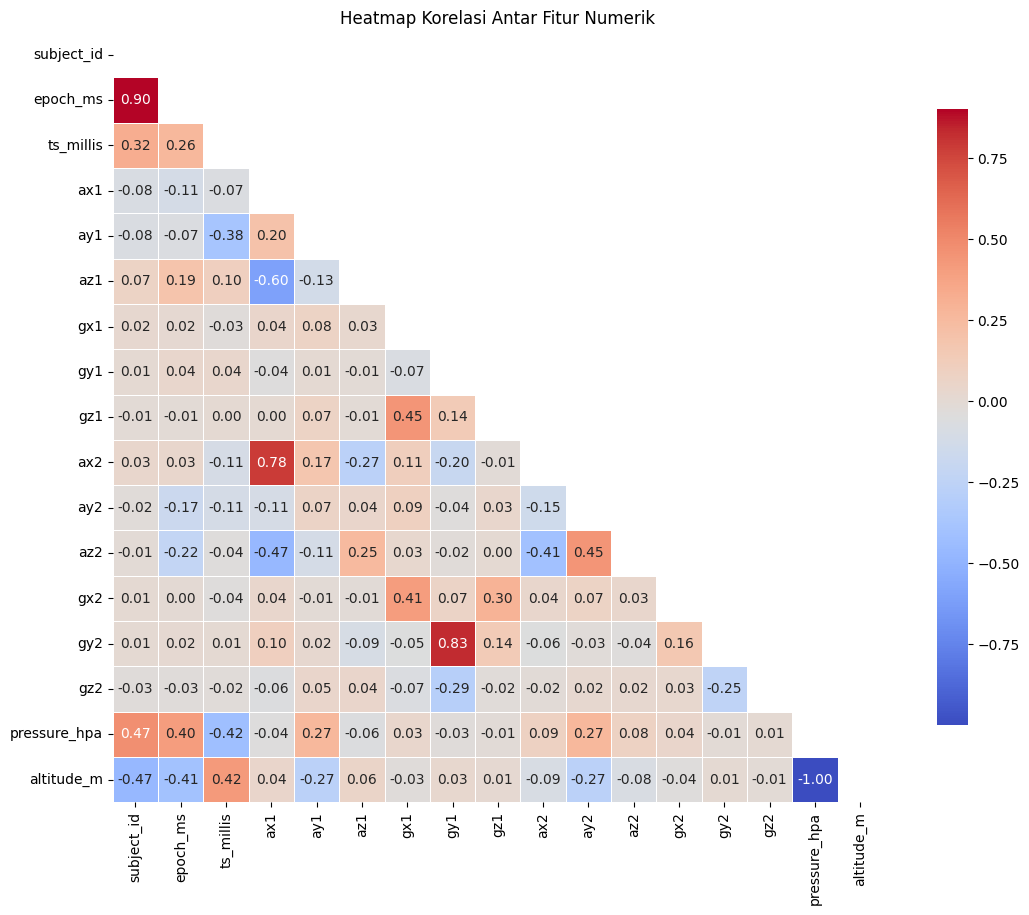


⚠️ Pasangan fitur dengan korelasi sangat tinggi (>|0.9|):
   subject_id & epoch_ms : 0.901
   pressure_hpa & altitude_m : -1.000


In [10]:
# Cell EDA 4: Heatmap korelasi (hanya kolom numerik)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
if len(num_cols) > 1:
    corr = df[num_cols].corr()
    plt.figure(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f',
                linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
    plt.title('Heatmap Korelasi Antar Fitur Numerik')
    plt.show()

    # Cari pasangan fitur dengan korelasi tinggi (>0.9 atau <-0.9)
    high_corr = []
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            if abs(corr.iloc[i, j]) > 0.9:
                high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))
    if high_corr:
        print("\n⚠️ Pasangan fitur dengan korelasi sangat tinggi (>|0.9|):")
        for pair in high_corr:
            print(f"   {pair[0]} & {pair[1]} : {pair[2]:.3f}")
    else:
        print("\n✅ Tidak ada pasangan fitur dengan korelasi >|0.9|.")
else:
    print("Tidak cukup kolom numerik untuk korelasi.")


## Analisi Variabel Target

ANALISIS TARGET: 'label'
Jumlah unik value: 4

Value counts:
label
benar      4852
salah      4028
berdiri    3995
              3
Name: count, dtype: int64


/tmp/ipykernel_7268/622614518.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[target_col], order=df[target_col].value_counts().index, palette='Set2')


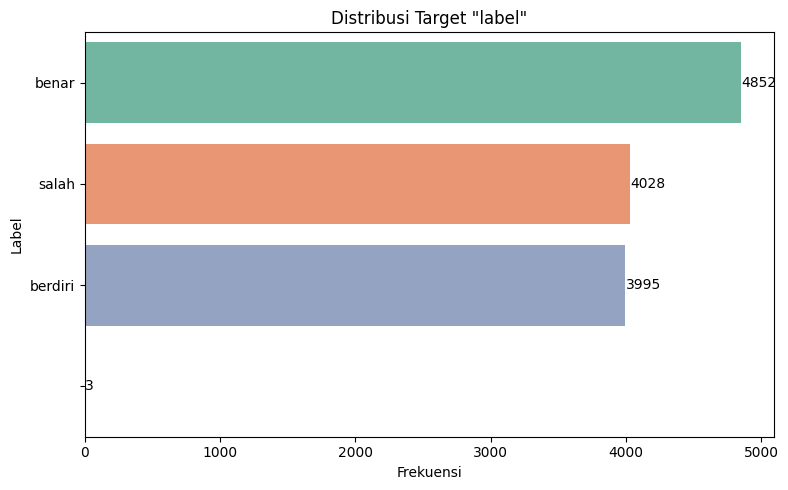


Rasio kelas minoritas/mayoritas: 0.001
⚠️ Dataset tidak seimbang (imbalance). Pertimbangkan teknik resampling nanti.


In [11]:
# Cell EDA 5: Analisis target (kolom 'label')
target_col = 'label'  # sesuai dengan data Anda

if target_col in df.columns:
    print("="*50)
    print(f"ANALISIS TARGET: '{target_col}'")
    print("="*50)

    print("Jumlah unik value:", df[target_col].nunique())
    print("\nValue counts:")
    print(df[target_col].value_counts())

    # Visualisasi distribusi target
    plt.figure(figsize=(8, 5))
    sns.countplot(y=df[target_col], order=df[target_col].value_counts().index, palette='Set2')
    plt.title(f'Distribusi Target "{target_col}"')
    plt.xlabel('Frekuensi')
    plt.ylabel('Label')
    for i, v in enumerate(df[target_col].value_counts().values):
        plt.text(v + 2, i, str(v), va='center')
    plt.tight_layout()
    plt.show()

    # Cek apakah target seimbang (untuk klasifikasi)
    counts = df[target_col].value_counts()
    min_class = counts.min()
    max_class = counts.max()
    imbalance_ratio = min_class / max_class
    print(f"\nRasio kelas minoritas/mayoritas: {imbalance_ratio:.3f}")
    if imbalance_ratio < 0.2:
        print("⚠️ Dataset tidak seimbang (imbalance). Pertimbangkan teknik resampling nanti.")
    else:
        print("✅ Dataset cukup seimbang.")
else:
    print(f"Kolom target '{target_col}' tidak ditemukan. Silakan cek nama kolom.")

# Cleaning Data

## Handle Missing Values & Hapus Kolom Non-Fitur

In [12]:
# Cell Cleaning 1: Tangani missing values dan hapus kolom yang tidak diperlukan
df_clean = df.copy()

# 1. Hapus kolom yang tidak diperlukan (identitas, waktu, metadata)
cols_to_drop = ['subject_id', 'nama', 'date', 'time', 'epoch_ms', 'ts_millis']
cols_exist = [c for c in cols_to_drop if c in df_clean.columns]
df_clean.drop(columns=cols_exist, inplace=True)
print(f"Kolom yang dihapus: {cols_exist}")
print(f"Kolom tersisa: {df_clean.columns.tolist()}")

# Define all sensor columns that should be numeric
sensor_numeric_cols = [
    'ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1',
    'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2',
    'pressure_hpa', 'altitude_m'
]

# 2. Ensure all sensor columns are numeric and fill NaNs introduced by coercion
print("\nConverting sensor columns to numeric and filling NaNs...")
for col in sensor_numeric_cols:
    if col in df_clean.columns:
        # Convert to numeric, coercing non-numeric values to NaN
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        # If NaNs are introduced or already exist, fill them with the median of the column
        if df_clean[col].isnull().any():
            # Calculate median on the *numeric* part of the column
            median_val = df_clean[col].median()
            # If median is NaN (e.g., if column was all NaNs or empty after coerce), use 0 as a fallback
            if pd.isna(median_val):
                median_val = 0.0 # Ensure it's a float
            df_clean[col] = df_clean[col].fillna(median_val)

# 3. Tangani general missing values (after numeric conversion)
print("\nMissing values before final NaN drop:")
print(df_clean.isnull().sum())

df_clean.dropna(inplace=True)
print(f"\nSetelah drop NA, jumlah baris: {len(df_clean)}")

# Cek ulang missing values
print("\nMissing values after handling:")
print(df_clean.isnull().sum())

Kolom yang dihapus: ['subject_id', 'nama', 'date', 'time', 'epoch_ms', 'ts_millis']
Kolom tersisa: ['ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'pressure_hpa', 'altitude_m', 'label', 'source_file']

Converting sensor columns to numeric and filling NaNs...

Missing values before final NaN drop:
ax1                0
ay1                0
az1                0
gx1                0
gy1                0
gz1                0
ax2                0
ay2                0
az2                0
gx2                0
gy2                0
gz2                0
pressure_hpa       0
altitude_m         0
label           1530
source_file        0
dtype: int64

Setelah drop NA, jumlah baris: 12878

Missing values after handling:
ax1             0
ay1             0
az1             0
gx1             0
gy1             0
gz1             0
ax2             0
ay2             0
az2             0
gx2             0
gy2             0
gz2             0
pressure_hpa    0
altitude_m  

## Encoding Target Label

In [13]:
import pandas as pd
import numpy as np

# Bersihkan label terlebih dahulu: hapus spasi, lowercase
df_clean['label_clean'] = df_clean['label'].astype(str).str.strip().str.lower()

# Hapus baris di mana 'label_clean' adalah string kosong
# Ini menangani kasus seperti "    " yang menjadi ""
initial_rows = len(df_clean)
df_clean = df_clean[df_clean['label_clean'] != ''].copy() # Explicitly create a copy
if len(df_clean) < initial_rows:
    print(f"Dihapus {initial_rows - len(df_clean)} baris dengan label kosong setelah pembersihan.")

# Mapping yang konsisten (pastikan nilai persis)
label_mapping = {'benar': 1, 'salah': 0, 'berdiri': 2}

df_clean['label_encoded'] = df_clean['label'].str.strip().str.lower().map(label_mapping)
assert df_clean['label_encoded'].isna().sum() == 0

# Validasi: tidak boleh ada NaN
if df_clean['label_encoded'].isna().any():
    problematic = df_clean[df_clean['label_encoded'].isna()]['label_clean'].unique()
    raise ValueError(f"Label tidak dikenal: {problematic}")

# Hapus kolom bantu jika perlu
df_clean.drop(columns=['label_clean'], inplace=True)

print("Distribusi target encoded:")
print(df_clean['label_encoded'].value_counts())

X = df_clean.drop(columns=['label', 'label_encoded'])
y = df_clean['label_encoded']

Dihapus 3 baris dengan label kosong setelah pembersihan.
Distribusi target encoded:
label_encoded
1    4852
0    4028
2    3995
Name: count, dtype: int64


In [14]:
# Pisahkan kolom grup subjek dari fitur
# 'source_file' berisi nama file CSV per subjek
subject_col = 'source_file'

groups = df_clean[subject_col].values          # array identitas subjek per baris
X      = df_clean.drop(columns=['label', 'label_encoded', subject_col])
y      = df_clean['label_encoded']

subjek_unik = np.unique(groups)
print(f"Total subjek: {len(subjek_unik)}")
print(f"Daftar subjek: {subjek_unik}")

Total subjek: 20
Daftar subjek: ['01-alifi.csv' '02-anisa.csv' '04-kelvin.csv' '05-saldina.csv'
 '06-taufik.csv' '07-alam.csv' '08-landa.csv' '11-muji.csv' '12-sofi.csv'
 '13-sutri.csv' '14-sultan.csv' '16-arlin.csv' '17-dika.csv'
 '18-fateh.csv' '19-nahwa.csv' '20-padli.csv' '21-rina.csv' '22-yunda.csv'
 '23-brian.csv' '24-ilmi.csv']


In [15]:
import numpy as np
import pandas as pd

print("="*50)
print("OUTLIER ANALYSIS (IQR METHOD)")
print("="*50)

# Identify numerical columns for outlier analysis
# Exclude 'label_encoded' and 'source_file' as they are not sensor features.
# Also exclude any metadata that might have been left if not dropped earlier.
feature_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
if 'label_encoded' in feature_cols:
    feature_cols.remove('label_encoded')

print(f"Analyzing {len(feature_cols)} numerical features for outliers...")

outlier_summary = []

for col in feature_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    num_outliers = len(outliers)
    percent_outliers = (num_outliers / len(df_clean)) * 100

    outlier_summary.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Number of Outliers': num_outliers,
        'Percentage of Outliers': f'{percent_outliers:.2f}%'
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

# Summarize overall outlier presence
total_outliers_count = 0
for col in feature_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    total_outliers_count += len(df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)])

if total_outliers_count > 0:
    print(f"\n⚠️ Total {total_outliers_count} data points identified as outliers across all features.")
    print("Pertimbangkan untuk menangani outlier ini (misalnya, capping, removal, atau transformasi) pada tahap preprocessing.")
else:
    print("\n✅ Tidak ada outlier yang teridentifikasi menggunakan metode IQR pada fitur numerik.")

# Optional: Visualize outliers for a few selected columns with box plots if needed
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Choose a few columns to visualize (e.g., top 3 with most outliers)
# cols_to_visualize = outlier_df.sort_values(by='Number of Outliers', ascending=False)['Feature'].head(3).tolist()

# if cols_to_visualize:
#     print(f"\nVisualisasi Boxplot untuk beberapa fitur dengan outlier teratas: {cols_to_visualize}")
#     plt.figure(figsize=(15, 5))
#     for i, col in enumerate(cols_to_visualize):
#         plt.subplot(1, len(cols_to_visualize), i + 1)
#         sns.boxplot(y=df_clean[col])
#         plt.title(f'Boxplot of {col}')
#         plt.ylabel(col)
#     plt.tight_layout()
#     plt.show()


OUTLIER ANALYSIS (IQR METHOD)
Analyzing 14 numerical features for outliers...


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers,Percentage of Outliers
0,ax1,0.44470,1.000240,0.555540,-0.388610,1.833550,714,5.55%
1,ay1,-0.08643,0.087160,0.173590,-0.346815,0.347545,410,3.18%
2,az1,0.33350,0.839965,0.506465,-0.426198,1.599663,19,0.15%
3,gx1,-8.38550,7.038000,15.423500,-31.520750,30.173250,1478,11.48%
4,gy1,-16.55350,14.550000,31.103500,-63.208750,61.205250,2356,18.30%
5,gz1,-4.75950,3.763000,8.522500,-17.543250,16.546750,1490,11.57%
6,ax2,0.68335,1.000730,0.317380,0.207280,1.476800,1345,10.45%
7,ay2,-0.06531,0.308960,0.374270,-0.626715,0.870365,34,0.26%
8,az2,0.14917,0.816410,0.667240,-0.851690,1.817270,2,0.02%
9,gx2,-10.98850,9.340000,20.328500,-41.481250,39.832750,1402,10.89%



⚠️ Total 17116 data points identified as outliers across all features.
Pertimbangkan untuk menangani outlier ini (misalnya, capping, removal, atau transformasi) pada tahap preprocessing.


## Visualisasi Outlier


Visualisasi Boxplot untuk 5 fitur dengan outlier terbanyak: ['gy1', 'gy2', 'pressure_hpa', 'altitude_m', 'gz2']


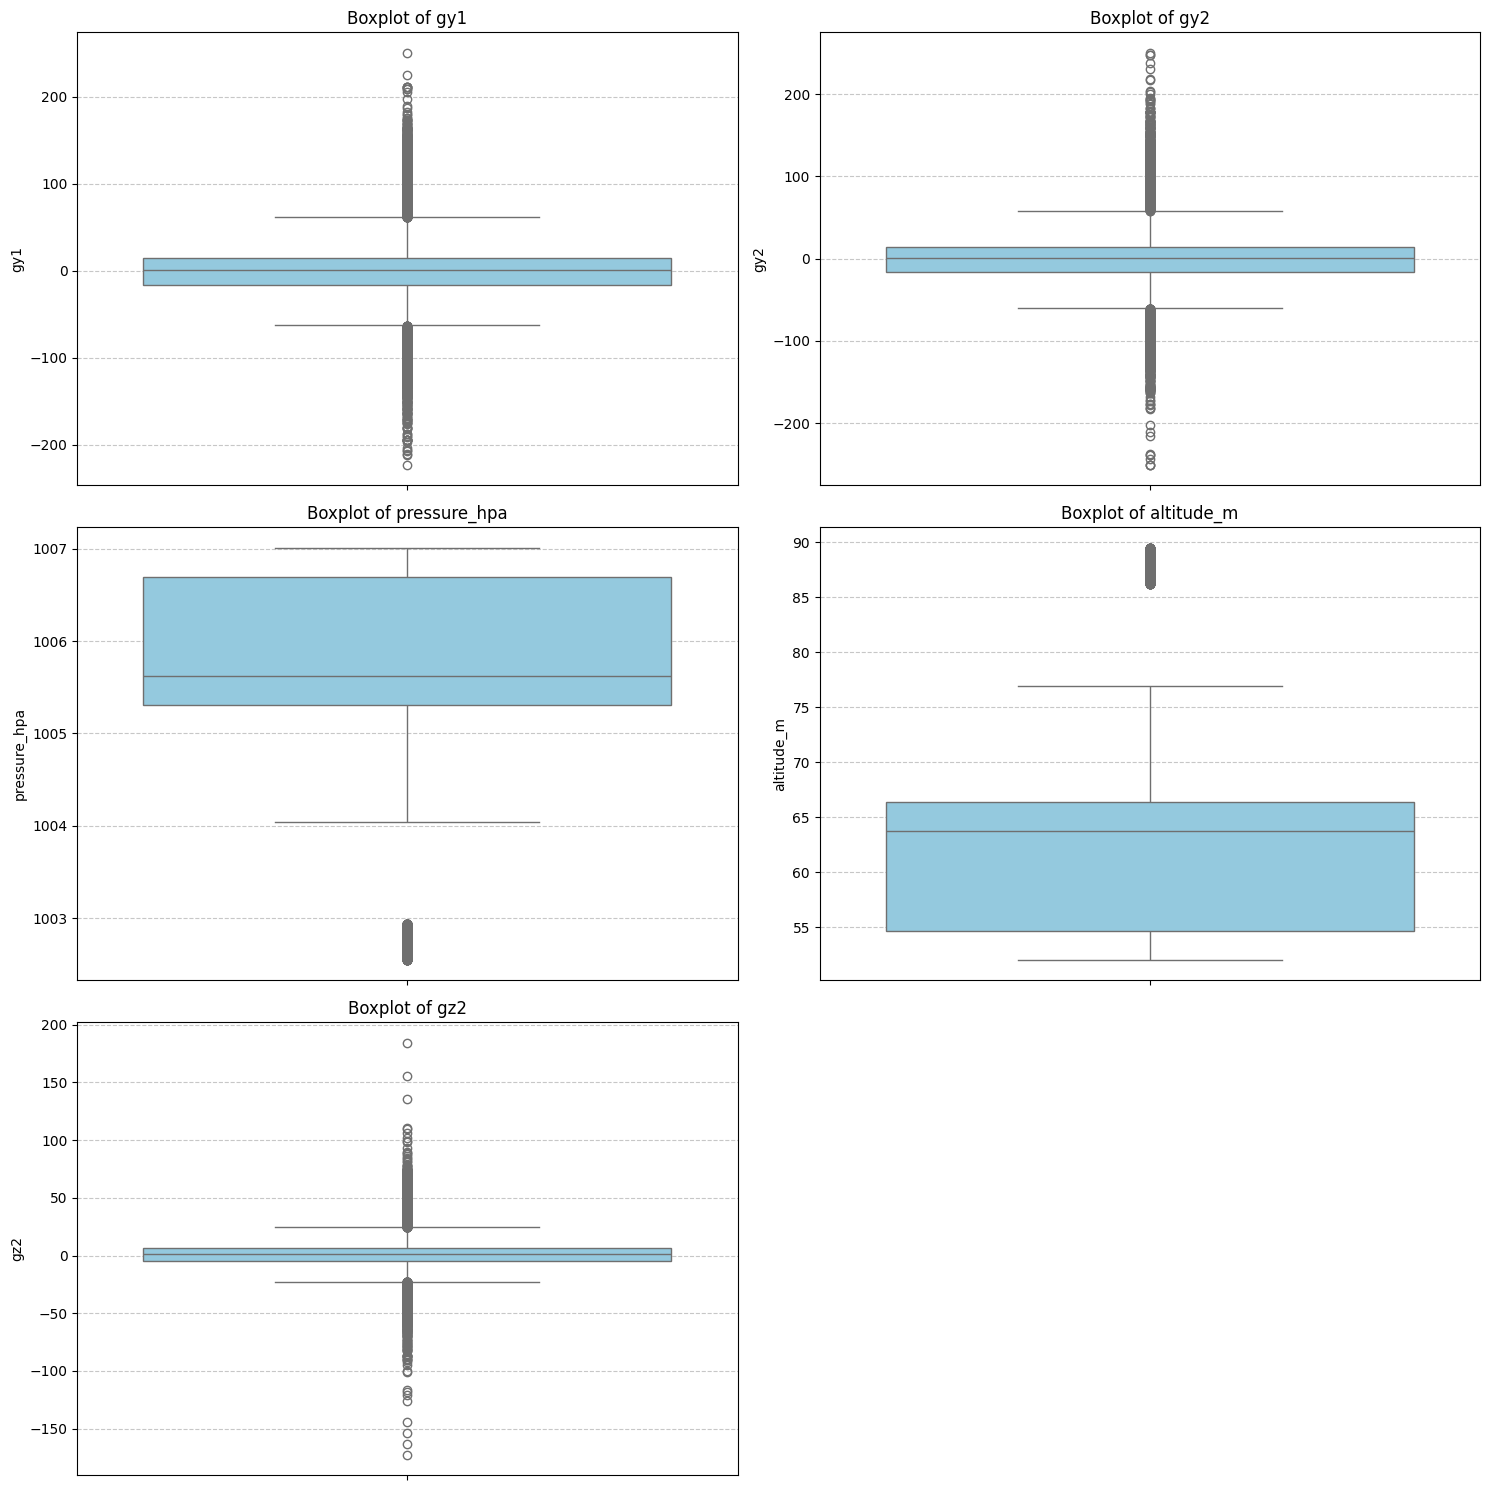

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose the top N columns to visualize based on the 'Number of Outliers' from the previous analysis
# Assuming 'outlier_df' is available from the previous outlier analysis cell.
# If not, the previous cell (NbpHABuvLvmj) needs to be run first.

n_cols_to_visualize = 5 # Adjust as needed
cols_to_visualize = outlier_df.sort_values(
    by='Number of Outliers', ascending=False
)['Feature'].head(n_cols_to_visualize).tolist()

if cols_to_visualize:
    print(f"\nVisualisasi Boxplot untuk {n_cols_to_visualize} fitur dengan outlier terbanyak: {cols_to_visualize}")

    # Determine the number of rows needed for the subplots
    n_rows = (len(cols_to_visualize) + 1) // 2 # 2 columns per row
    fig, axes = plt.subplots(n_rows, 2, figsize=(15, 5 * n_rows))
    axes = axes.flatten() # Flatten for easy iteration

    for i, col in enumerate(cols_to_visualize):
        sns.boxplot(y=df_clean[col], ax=axes[i], color='skyblue')
        axes[i].set_title(f'Boxplot of {col}')
        axes[i].set_ylabel(col)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    # Remove any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show()
else:
    print("Tidak ada fitur untuk divisualisasikan, atau outlier_df tidak tersedia/kosong.")


## Penanganan Outlier

Frekuensi sampling yang digunakan: 5.00 Hz

Kolom sensor yang dianalisis: ['ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'pressure_hpa', 'altitude_m']


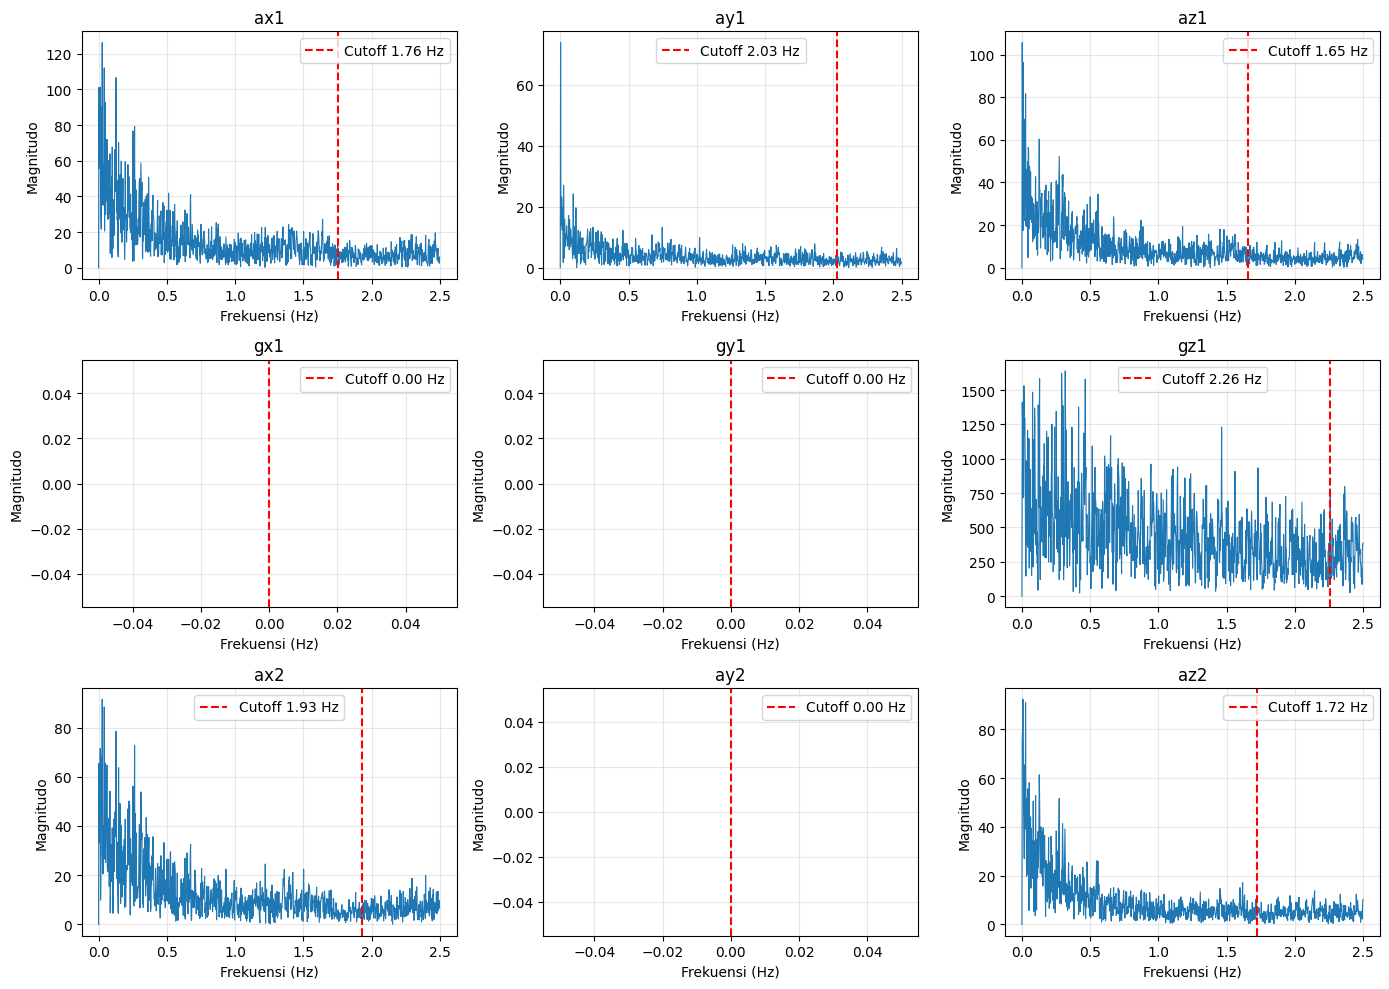


=== Rekomendasi Parameter Filter ===
Butterworth low-pass cutoff: berdasarkan FFT, disarankan sekitar 1.72 Hz
   (rentang: 0.00 - 2.26 Hz)
Kalman filter:
   Measurement variance (R) ≈ 0.056575 (gunakan nilai sekitar ini)
   Process variance (Q) ≈ 21.782032 (gunakan nilai sekitar ini)


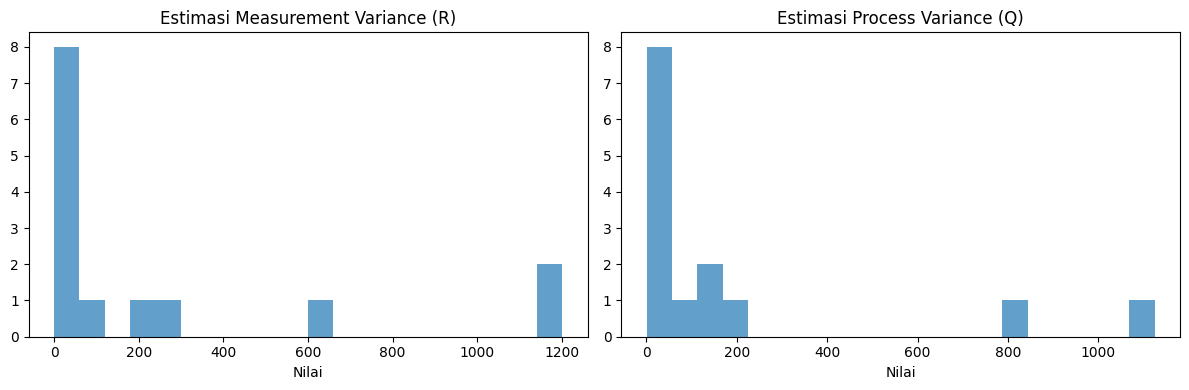

In [17]:
# Cell Analisis Frekuensi dan Noise untuk Filter (sebelum outlier detection)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import periodogram

# ====================================================
# 1. Hitung frekuensi sampling dari timestamp
# ====================================================
# Hitung sampling frequency dari timestamp (sama seperti di sel FFT)
if 'epoch_ms' in df.columns:
    timestamps = df['epoch_ms'].values
elif 'ts_millis' in df.columns:
    timestamps = df['ts_millis'].values
else:
    timestamps = np.arange(len(df))

diffs = np.diff(timestamps) / 1000.0  # dalam detik
median_dt = np.median(diffs)
sampling_freq = 1.0 / median_dt if median_dt > 0 else 50.0
print(f"Frekuensi sampling yang digunakan: {sampling_freq:.2f} Hz")

# ====================================================
# 2. Pilih kolom sensor numerik (abaikan label, subject_id, dll)
# ====================================================
ignore_cols = ['subject_id', 'nama', 'date', 'time', 'epoch_ms', 'ts_millis',
               'source_file', 'datetime', 'label', 'label_encoded']
sensor_cols = [c for c in df.columns if c not in ignore_cols and np.issubdtype(df[c].dtype, np.number)]

print(f"\nKolom sensor yang dianalisis: {sensor_cols}")

# ====================================================
# 3. Analisis FFT untuk setiap sensor (ambil sampel 2048 points untuk efisiensi)
# ====================================================
n_fft = min(2048, len(df))
freqs = fftfreq(n_fft, d=median_dt)
pos_mask = freqs > 0

# Simpan rekomendasi cutoff untuk setiap sensor
cutoff_recommendations = {}

plt.figure(figsize=(14, 10))
for i, col in enumerate(sensor_cols[:9]):  # maksimal 9 subplot
    data = df[col].values[:n_fft]
    # Detrend sederhana
    data = data - np.mean(data)
    # FFT
    fft_vals = np.abs(fft(data))[:n_fft//2]
    f = freqs[:n_fft//2]

    # Cari frekuensi di mana 95% energi berada
    psd = fft_vals**2
    cumulative_energy = np.cumsum(psd) / np.sum(psd)
    cutoff_idx = np.searchsorted(cumulative_energy, 0.95)
    cutoff_freq = f[cutoff_idx] if cutoff_idx < len(f) else f[-1]
    cutoff_recommendations[col] = cutoff_freq

    plt.subplot(3, 3, i+1)
    plt.plot(f, fft_vals, linewidth=0.8)
    plt.axvline(cutoff_freq, color='r', linestyle='--', label=f'Cutoff {cutoff_freq:.2f} Hz')
    plt.title(f'{col}')
    plt.xlabel('Frekuensi (Hz)')
    plt.ylabel('Magnitudo')
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

# ====================================================
# 4. Estimasi noise variance (R) dan process variance (Q) untuk Kalman
# ====================================================
# Metode: gunakan differencing orde pertama untuk estimasi noise
# Asumsi: sinyal = state + noise, state berubah lambat
noise_vars = []
process_vars = []

for col in sensor_cols:
    data = df[col].dropna().values
    if len(data) < 10:
        continue
    # Estimasi noise: variansi dari high-pass residual (selisih orde pertama)
    diff = np.diff(data)
    # Asumsikan perubahan state lambat, noise mendominasi pada diff
    # Estimasi R = variansi dari diff / 2 (karena diff = noise_t+1 - noise_t)
    R_est = np.var(diff) / 2.0
    # Estimasi Q: variansi dari perubahan state yang dihaluskan (low-pass)
    # Alternatif: Q = variansi dari perubahan sinyal setelah smoothing
    # Di sini kita gunakan variansi dari sinyal original dikurangi estimasi noise
    Q_est = max(0.01, np.var(data) - R_est)  # ensure positive
    noise_vars.append(R_est)
    process_vars.append(Q_est)

# Rata-rata rekomendasi
median_R = np.median(noise_vars) if noise_vars else 1e-2
median_Q = np.median(process_vars) if process_vars else 1e-5

print(f"\n=== Rekomendasi Parameter Filter ===")
print(f"Butterworth low-pass cutoff: berdasarkan FFT, disarankan sekitar {np.median(list(cutoff_recommendations.values())):.2f} Hz")
print(f"   (rentang: {min(cutoff_recommendations.values()):.2f} - {max(cutoff_recommendations.values()):.2f} Hz)")
print(f"Kalman filter:")
print(f"   Measurement variance (R) ≈ {median_R:.6f} (gunakan nilai sekitar ini)")
print(f"   Process variance (Q) ≈ {median_Q:.6f} (gunakan nilai sekitar ini)")

# ====================================================
# 5. Visualisasi distribusi noise dan sinyal (opsional)
# ====================================================
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.hist(noise_vars, bins=20, alpha=0.7)
plt.title('Estimasi Measurement Variance (R)')
plt.xlabel('Nilai')
plt.subplot(1,2,2)
plt.hist(process_vars, bins=20, alpha=0.7)
plt.title('Estimasi Process Variance (Q)')
plt.xlabel('Nilai')
plt.tight_layout()
plt.show()

# Preprocessing

## Split Data Train-Test

In [18]:
# # Cell Preprocessing 1: Split data menjadi train dan test
# from sklearn.model_selection import train_test_split

# split_idx = int(len(X) * 0.8)
# X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
# y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# print(f"Train: {X_train.shape}, Test: {X_test.shape}")
# print("Distribusi y_train:", y_train.value_counts(normalize=True).to_dict())
# print("Distribusi y_test:", y_test.value_counts(normalize=True).to_dict())

## Filtering

In [19]:
# Cell Preprocessing: Filtering (Kalman & Butterworth)
# Place this cell BEFORE outlier detection (after cleaning, before windowing)

from scipy.signal import butter, filtfilt, lfilter
import numpy as np

def butterworth_filter_causal(data, cutoff, fs, order=4, btype='low'):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype=btype, analog=False)
    # lfilter -> causal (hanya data masa lalu)
    return lfilter(b, a, data)

def kalman_filter_1d(data, process_variance=1e-5, measurement_variance=1e-2):
    """
    Simple 1D Kalman filter for smoothing.

    Parameters:
    data (array): 1D signal
    process_variance (float): Q - process noise covariance
    measurement_variance (float): R - measurement noise covariance

    Returns:
    filtered (array): filtered signal
    """
    n = len(data)
    filtered = np.zeros(n)
    # Initial state estimate and error covariance
    x_est = data[0]
    P_est = 1.0

    for i in range(n):
        # Prediction
        x_pred = x_est
        P_pred = P_est + process_variance

        # Update
        K = P_pred / (P_pred + measurement_variance)  # Kalman gain
        x_est = x_pred + K * (data[i] - x_pred)
        P_est = (1 - K) * P_pred
        filtered[i] = x_est

    return filtered

# ========== USER ADJUSTABLE PARAMETERS ==========
# --- Butterworth settings ---
use_butterworth = False         # Set False to skip
butter_cutoff = 5.0            # Cutoff frequency (Hz)
butter_order = 5               # Filter order

# --- Kalman settings ---
use_kalman = False              # Set False to skip
kalman_process_var = 0.001      # Process noise variance
kalman_measurement_var = 0.1  # Measurement noise variance

# ================================================

# # Apply filters to each numeric column (excluding label)
# numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
# # Note: X here is the feature DataFrame after cleaning, before windowing (time series)

# if use_butterworth or use_kalman:
#     print("Menerapkan filter ke setiap kolom numerik...")
#     for col in numeric_cols:
#         data = X_train[col].values
#         if use_butterworth:
#             data = butterworth_filter_causal(data, butter_cutoff, sampling_freq, butter_order)
#         if use_kalman:
#             data = kalman_filter_1d(data, kalman_process_var, kalman_measurement_var)
#         X_train[col] = data
#     print("Filter selesai diterapkan.")
# else:
#     print("Tidak ada filter yang diterapkan.")


In [20]:
# # Cell Perbandingan Sebelum dan Sesudah Filtering (tanpa modifikasi data)

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # ------------------------------------------------------------------
# # 1. Ambil data asli (sebelum filtering) dari df_clean
# #    Asumsi: df_clean masih berisi nilai sensor asli (belum difilter)
# #    dan X adalah DataFrame hasil filtering (sudah dimodifikasi)
# # ------------------------------------------------------------------
# # Kolom sensor yang digunakan dalam filtering (numeric_cols)
# numeric_cols = X_train.columns.tolist()  # karena X setelah filtering

# # Buat DataFrame asli dari df_clean hanya untuk kolom yang sama
# if 'df_clean' in globals():
#     original_data = df_clean[numeric_cols].copy()
#     print("Data asli (sebelum filtering) diambil dari df_clean.")
# else:
#     # fallback: jika df_clean tidak ada, coba gunakan X_original (jika ada)
#     if 'X_original' in globals():
#         original_data = X[numeric_cols].copy()
#         print("Data asli (sebelum filtering) diambil dari X_original.")
#     else:
#         raise NameError("Tidak ditemukan data asli (df_clean atau X_original).")

# # Data setelah filtering sudah ada di X
# filtered_data = X[numeric_cols].copy()
# print(f"Data setelah filtering diambil dari X (shape: {filtered_data.shape})")

# # ------------------------------------------------------------------
# # 2. Pilih beberapa kolom sensor untuk visualisasi (maksimal 6)
# # ------------------------------------------------------------------
# sample_cols = numeric_cols[:6]  # ambil 6 kolom pertama
# n_cols = len(sample_cols)

# # ------------------------------------------------------------------
# # 3. Plot perbandingan sinyal (500 sampel pertama)
# # ------------------------------------------------------------------
# fig, axes = plt.subplots(n_cols, 2, figsize=(14, 3*n_cols))
# if n_cols == 1:
#     axes = axes.reshape(1, -1)

# for i, col in enumerate(sample_cols):
#     # Sinyal asli dan setelah filter (500 poin pertama)
#     orig = original_data[col].values[:500]
#     filt = filtered_data[col].values[:500]

#     # Plot sinyal asli
#     axes[i, 0].plot(orig, label='Original', alpha=0.6, linewidth=0.8)
#     axes[i, 0].set_title(f'{col} - Original (sebelum filter)')
#     axes[i, 0].set_xlabel('Sampel ke-')
#     axes[i, 0].set_ylabel('Nilai')
#     axes[i, 0].legend()
#     axes[i, 0].grid(True, alpha=0.3)

#     # Plot sinyal setelah filter
#     axes[i, 1].plot(filt, label='Filtered', color='orange', alpha=0.6, linewidth=0.8)
#     axes[i, 1].set_title(f'{col} - Setelah Filter (Butterworth+Kalman)')
#     axes[i, 1].set_xlabel('Sampel ke-')
#     axes[i, 1].set_ylabel('Nilai')
#     axes[i, 1].legend()
#     axes[i, 1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # ------------------------------------------------------------------
# # 4. Statistik ringkasan (mean, std, min, max) untuk semua kolom
# # ------------------------------------------------------------------
# stats_orig = original_data.describe().T[['mean', 'std', 'min', 'max']]
# stats_filt = filtered_data.describe().T[['mean', 'std', 'min', 'max']]

# # Gabungkan untuk perbandingan
# stats_comp = pd.DataFrame({
#     'mean_orig': stats_orig['mean'],
#     'mean_filt': stats_filt['mean'],
#     'std_orig': stats_orig['std'],
#     'std_filt': stats_filt['std'],
#     'min_orig': stats_orig['min'],
#     'min_filt': stats_filt['min'],
#     'max_orig': stats_orig['max'],
#     'max_filt': stats_filt['max']
# })

# print("\n=== PERBANDINGAN STATISTIK (seluruh kolom) ===")
# print(stats_comp.round(4))

# # Hitung persen perubahan standar deviasi (indikator penurunan noise)
# stats_comp['std_change_%'] = ((stats_comp['std_filt'] - stats_comp['std_orig']) / stats_comp['std_orig']) * 100
# print("\n=== PERSENTASE PERUBAHAN STANDAR DEVIASI ===")
# print(stats_comp['std_change_%'].round(2))

# # ------------------------------------------------------------------
# # 5. Visualisasi distribusi selisih (original - filtered) untuk menilai noise
# # ------------------------------------------------------------------
# fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# axes = axes.flatten()
# for idx, col in enumerate(sample_cols):
#     diff = original_data[col].values - filtered_data[col].values
#     axes[idx].hist(diff, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
#     axes[idx].set_title(f'{col} - Selisih (Original - Filtered)')
#     axes[idx].set_xlabel('Selisih')
#     axes[idx].set_ylabel('Frekuensi')
#     axes[idx].grid(True, alpha=0.3)
# # Matikan axis yang tidak terpakai
# for j in range(len(sample_cols), len(axes)):
#     axes[j].set_visible(False)
# plt.tight_layout()
# plt.show()

# # ------------------------------------------------------------------
# # 6. Ringkasan pengaruh filtering (opsional)
# # ------------------------------------------------------------------
# print("\n=== KESIMPULAN AWAL ===")
# print(f"Rata-rata perubahan standar deviasi: {stats_comp['std_change_%'].mean():.2f}%")
# if stats_comp['std_change_%'].mean() < 0:
#     print("Filtering secara umum mengurangi variabilitas sinyal (noise berkurang).")
# else:
#     print("Filtering tidak secara konsisten mengurangi variabilitas; periksa parameter.")

## Scaling Fitur

In [22]:
# # Cell Preprocessing 2: Standarisasi fitur numerik (StandardScaler)

# # Standarisasi fitur numerik (X_train)

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_win)
# X_test_scaled = scaler.transform(X_test_win)

# # Konversi kembali ke DataFrame (opsional, untuk kemudahan)
# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_win.columns, index=X_train_win.index)
# X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_win.columns, index=X_test_win.index)

# print("Contoh statistik X_train_scaled:")
# display(X_train_scaled.describe())

In [23]:
import numpy as np
import pandas as pd

def add_derived_features(X_df):
    """
    Fitur turunan per baris — dihitung instan tanpa buffer.
    Menambah ~18 fitur dari 14 kolom sensor.
    """
    X = X_df.copy()

    # Ensure all relevant sensor columns are numeric and handle infinities/NaNs
    # This block is re-added as a safeguard due to persistent TypeError,
    # even though upstream cleaning is intended to handle it.
    sensor_numeric_cols = [
        'ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1',
        'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2',
        'pressure_hpa', 'altitude_m'
    ]
    for col in sensor_numeric_cols:
        if col in X.columns:
            # Convert to numeric, coercing non-numeric values to NaN
            X[col] = pd.to_numeric(X[col], errors='coerce')
            # Replace NaNs with 0
            X[col] = X[col].fillna(0)
            # Handle infinities, replace with 0
            X[col] = X[col].replace([np.inf, -np.inf], 0)

    # Magnitudo akselerometer (intensitas gerakan keseluruhan)
    if all(c in X.columns for c in ['ax1','ay1','az1']):
        X['acc_mag1'] = np.sqrt(X['ax1']**2 + X['ay1']**2 + X['az1']**2)
    if all(c in X.columns for c in ['ax2','ay2','az2']):
        X['acc_mag2'] = np.sqrt(X['ax2']**2 + X['ay2']**2 + X['az2']**2)

    # Magnitudo gyroscope (kecepatan rotasi)
    if all(c in X.columns for c in ['gx1','gy1','gz1']):
        X['gyro_mag1'] = np.sqrt(X['gx1']**2 + X['gy1']**2 + X['gz1']**2)
    if all(c in X.columns for c in ['gx2','gy2','gz2']):
        X['gyro_mag2'] = np.sqrt(X['gx2']**2 + X['gy2']**2 + X['gz2']**2)

    # Selisih antar sensor (perbedaan gerak antara dua titik tubuh)
    for axis in ['x','y','z']:
        for s in ['a','g']:
            c1, c2 = f'{s}{axis}1', f'{s}{axis}2'
            if c1 in X.columns and c2 in X.columns:
                X[f'diff_{s}{axis}'] = X[c1] - X[c2]

    # Sudut kemiringan / tilt (sangat relevan untuk postur mengangkat beban)
    if all(c in X.columns for c in ['ax1','ay1','az1']):
        # Adding a small epsilon to denominator to prevent division by zero, if any.
        X['roll1']  = np.arctan2(X['ay1'],
                                  np.sqrt(X['ax1']**2 + X['az1']**2) + 1e-9)
        X['pitch1'] = np.arctan2(-X['ax1'],
                                  np.sqrt(X['ay1']**2 + X['az1']**2) + 1e-9)
    if all(c in X.columns for c in ['ax2','ay2','az2']):
        X['roll2']  = np.arctan2(X['ay2'],
                                  np.sqrt(X['ax2']**2 + X['az2']**2) + 1e-9)
        X['pitch2'] = np.arctan2(-X['ax2'],
                                  np.sqrt(X['ay2']**2 + X['az2']**2) + 1e-9)

    # Beda sudut antar sensor (indikator ketidakselarasan postur)
    if all(c in X.columns for c in ['roll1','roll2']):
        X['diff_roll']  = X['roll1'] - X['roll2']
        X['diff_pitch'] = X['pitch1'] - X['pitch2'] # Corrected from X['roll1'] - X['roll2']

    return X


In [24]:
def add_rolling_features(X_df, n=3):
    """
    Rolling pendek HANYA pada fitur kunci.
    N=3 di 5Hz = 0.6 detik delay.
    Hanya 10 fitur tambahan, bukan semua kolom.
    """
    X = X_df.copy()

    # Pilih hanya fitur yang paling relevan untuk rolling
    key_cols = [c for c in ['acc_mag1','acc_mag2','gyro_mag1','gyro_mag2',
                             'roll1','pitch1','diff_roll','diff_pitch']
                if c in X.columns]

    for col in key_cols:
        # Ensure column is numeric before rolling operation
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)
        X[f'{col}_rm{n}'] = (X[col].rolling(n, min_periods=1)
                                   .mean())
        X[f'{col}_rs{n}'] = (X[col].rolling(n, min_periods=1)
                                   .std()
                                   .fillna(0))
    return X

def add_rolling_per_subject(X_df, y_df, groups_arr, n=3):
    """Rolling dihitung ulang per subjek agar tidak melewati batas."""
    parts_X, parts_y = [], []
    for subj in np.unique(groups_arr):
        mask = groups_arr == subj
        X_s = X_df[mask].copy()
        X_s = add_rolling_features(X_s, n=n)
        parts_X.append(X_s)
        parts_y.append(y_df[mask])
    return pd.concat(parts_X).reset_index(drop=True), \
           pd.concat(parts_y).reset_index(drop=True)

# Modelling LOSO

## Training

In [25]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd
from collections import Counter

# Ensure LABEL_BERDIRI is defined for filtering, as used in create_window_features previously
LABEL_BERDIRI = 2 # Corresponds to 'berdiri' in the original label mapping

# ── Simpan hasil tiap fold ──────────────────────────────────────────
lopo_results = []
all_y_true   = []
all_y_pred   = []
conf_matrices = {}

print(f"Memulai LOPO dengan {len(subjek_unik)} fold...\n")
print("="*60)

# Variables to store the last model and X_train_win for feature importance
rf_model = None
X_train_win_last_fold = None

for fold_idx, test_subject in enumerate(subjek_unik):

    # ── 1. Split berdasarkan subjek ─────────────────────────────────
    train_mask = groups != test_subject
    test_mask  = groups == test_subject

    X_train_raw = X[train_mask].reset_index(drop=True)
    y_train_raw = y[train_mask].reset_index(drop=True)
    X_test_raw  = X[test_mask].reset_index(drop=True)
    y_test_raw  = y[test_mask].reset_index(drop=True)

    # Filter out 'Berdiri' (label 2) from raw data
    # This maintains the 2-class problem as established by previous modifications
    train_mask_filtered = y_train_raw != LABEL_BERDIRI
    test_mask_filtered  = y_test_raw  != LABEL_BERDIRI

    X_train_filtered = X_train_raw[train_mask_filtered].reset_index(drop=True)
    y_train_filtered = y_train_raw[train_mask_filtered].reset_index(drop=True)
    X_test_filtered  = X_test_raw[test_mask_filtered].reset_index(drop=True)
    y_test_filtered  = y_test_raw[test_mask_filtered].reset_index(drop=True)

    #Add derived features
    X_train_filtered = add_derived_features(X_train_filtered)
    X_test_filtered  = add_derived_features(X_test_filtered)

    # Add rolling features, ensuring it's applied to both train and test with correct groups
    groups_train = groups[train_mask][y[train_mask] != LABEL_BERDIRI]
    X_train_filtered, y_train_filtered = add_rolling_per_subject(
        X_train_filtered, y_train_filtered, groups_train
    )

    groups_test = groups[test_mask][y[test_mask] != LABEL_BERDIRI]
    X_test_filtered, y_test_filtered = add_rolling_per_subject(
        X_test_filtered, y_test_filtered, groups_test
    )

    # ── 2. Menggunakan data mentah (raw) tanpa windowing ─────────────
    # X_train_win dan y_train_win sekarang adalah data mentah yang sudah difilter
    # Ini menggantikan panggilan create_window_features
    X_train_win = X_train_filtered
    y_train_win = y_train_filtered
    X_test_win  = X_test_filtered
    y_test_win  = y_test_filtered

    # Remove the lines dropping 'zero_crossing' features as they are generated by windowing
    # and thus will not exist in the raw data.
    # X_train_win = X_train_win.drop(columns=zero_features, errors='ignore')
    # X_test_win  = X_test_win.drop(columns=zero_features, errors='ignore')

    # Cara paling bersih (tanpa warning, tanpa downcasting otomatis)
    X_train_win = X_train_win.replace([np.inf, -np.inf], 0).fillna(0)
    X_test_win  = X_test_win.replace([np.inf, -np.inf], 0).fillna(0)

    # Skip fold jika data terlalu sedikit
    if len(X_train_win) == 0 or len(X_test_win) == 0:
        print(f"  ⚠ Fold {fold_idx+1} dilewati (data terlalu sedikit setelah filter)\n")
        continue

    # ── 3. Scaling (fit HANYA di train) ────────────────────────────
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train_win)
    X_test_scaled  = scaler.transform(X_test_win)

    # ── 4. Training ─────────────────────────────────────────────────
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=1,
        max_features='sqrt',
        bootstrap=True,
        class_weight='balanced',
        criterion='gini',
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_scaled, y_train_win)

    # ── 5. Evaluasi fold ini ────────────────────────────────────────
    y_pred = model.predict(X_test_scaled)
    # Update confusion_matrix labels to reflect the 2 classes ('Salah', 'Benar')
    cm_fold = confusion_matrix(y_test_win, y_pred, labels=[0, 1])
    acc    = accuracy_score(y_test_win, y_pred)
    conf_matrices[test_subject] = cm_fold

    lopo_results.append({
        'fold'          : fold_idx + 1,
        'test_subject'  : test_subject,
        'n_train_samples': len(y_train_win), # Changed from windows to samples
        'n_test_samples' : len(y_test_win),  # Changed from windows to samples
        'accuracy'      : acc
    })

    all_y_true.extend(y_test_win.tolist())
    all_y_pred.extend(y_pred.tolist())

    print(f"Fold {fold_idx+1:2d} | Test: {test_subject:<30s} | "
          f"Acc: {acc:.4f} ({acc*100:.1f}%)")

    # Store the last trained model and its X_train_win for feature importance
    if fold_idx == len(subjek_unik) - 1: # Only store for the last fold
        rf_model = model
        X_train_win_last_fold = X_train_win # This is now the raw, filtered data for the last fold

print("="*60)

Memulai LOPO dengan 20 fold...

Fold  1 | Test: 01-alifi.csv                   | Acc: 0.8587 (85.9%)
Fold  2 | Test: 02-anisa.csv                   | Acc: 0.8568 (85.7%)
Fold  3 | Test: 04-kelvin.csv                  | Acc: 0.7774 (77.7%)
Fold  4 | Test: 05-saldina.csv                 | Acc: 0.8004 (80.0%)
Fold  5 | Test: 06-taufik.csv                  | Acc: 0.8237 (82.4%)
Fold  6 | Test: 07-alam.csv                    | Acc: 0.8232 (82.3%)
Fold  7 | Test: 08-landa.csv                   | Acc: 0.8464 (84.6%)
Fold  8 | Test: 11-muji.csv                    | Acc: 0.7602 (76.0%)
Fold  9 | Test: 12-sofi.csv                    | Acc: 0.6862 (68.6%)
Fold 10 | Test: 13-sutri.csv                   | Acc: 0.7045 (70.4%)
Fold 11 | Test: 14-sultan.csv                  | Acc: 0.9485 (94.8%)
Fold 12 | Test: 16-arlin.csv                   | Acc: 0.9620 (96.2%)
Fold 13 | Test: 17-dika.csv                    | Acc: 0.9550 (95.5%)
Fold 14 | Test: 18-fateh.csv                   | Acc: 0.9524 (95.2%)
Fo

In [26]:
import pandas as pd
import numpy as np

print("=== EDA per Subjek (Distribusi Label dan Durasi) ===")

# Memastikan df_clean tersedia dan tidak kosong
if 'df_clean' in globals() and not df_clean.empty:
    # Menghitung distribusi label per subjek
    # Membersihkan dan mengganti label kosong/invalid untuk robustansi
    df_temp_labels = df_clean.copy()
    df_temp_labels['label_str'] = df_temp_labels['label'].astype(str).str.strip().replace('', 'UNKNOWN_LABEL')

    # Anonymize source_file to subject ID only for label distribution
    df_temp_labels['subject_id_anon'] = df_temp_labels['source_file'].apply(lambda x: x.split('-')[0] if '-' in x else x)

    # Calculate label distribution
    label_dist_df = df_temp_labels.groupby(['subject_id_anon', 'label_str'])['label_str'].count().unstack(fill_value=0)
    label_dist_df.index.name = 'test_subject_id'

    # Calculate duration per subject from the original 'df' dataframe
    duration_df = pd.DataFrame()
    if 'df' in globals() and not df.empty and 'epoch_ms' in df.columns:
        df_temp_duration = df[['source_file', 'epoch_ms']].copy()
        df_temp_duration['subject_id_anon'] = df_temp_duration['source_file'].apply(lambda x: x.split('-')[0] if '-' in x else x)

        duration_df = df_temp_duration.groupby('subject_id_anon').agg(
            duration_ms=('epoch_ms', lambda x: x.max() - x.min())
        ).reset_index()
        duration_df['duration_sec'] = duration_df['duration_ms'] / 1000
        duration_df.set_index('subject_id_anon', inplace=True)
    else:
        print("Peringatan: Kolom 'epoch_ms' atau dataframe 'df' tidak ditemukan, durasi tidak dapat dihitung.")

    # Merge label distribution with duration
    if not duration_df.empty:
        combined_eda_df = label_dist_df.join(duration_df[['duration_sec']], how='left')
    else:
        combined_eda_df = label_dist_df.copy()

    # Pastikan kolom label yang diharapkan ada, isi dengan 0 jika tidak ada
    for expected_label in ['benar', 'salah', 'berdiri']:
        if expected_label not in combined_eda_df.columns:
            combined_eda_df[expected_label] = 0
    # Hapus kolom 'UNKNOWN_LABEL' jika terbentuk
    if 'UNKNOWN_LABEL' in combined_eda_df.columns:
        combined_eda_df.drop(columns=['UNKNOWN_LABEL'], inplace=True)

    # Convert duration_sec to 'MM:SS' format
    if 'duration_sec' in combined_eda_df.columns:
        combined_eda_df['duration'] = combined_eda_df['duration_sec'].apply(
            lambda x: f"{int(x // 60)}:{int(x % 60):02d}" if pd.notna(x) else "N/A"
        )
        combined_eda_df.drop(columns=['duration_sec'], inplace=True)
        duration_col_name = 'duration'
    else:
        duration_col_name = None

    # Mengurutkan kolom untuk konsistensi
    label_cols_order = [col for col in ['benar', 'salah', 'berdiri'] if col in combined_eda_df.columns]
    other_cols = [col for col in combined_eda_df.columns if col not in label_cols_order and col != duration_col_name]

    final_cols_order = label_cols_order + other_cols
    if duration_col_name:
        final_cols_order.append(duration_col_name)

    combined_eda_df = combined_eda_df[final_cols_order].sort_values(by='test_subject_id')

    print("\n--- Distribusi Label dan Durasi per Subjek dari df_clean ---")
    display(combined_eda_df)

else:
    print("Dataframe 'df_clean' tidak ditemukan atau kosong. Pastikan sel preprocessing sudah dijalankan.")

=== EDA per Subjek (Distribusi Label dan Durasi) ===

--- Distribusi Label dan Durasi per Subjek dari df_clean ---


,benar,salah,berdiri,duration
test_subject_id,,,,
01,214,147,158,1:44
02,291,93,5,16:08
04,112,162,116,2:28
05,329,137,28,2:56
06,289,301,473,3:56
07,345,294,527,3:53
08,380,271,211,2:52
11,224,243,219,14:22
12,287,242,295,3:57


In [27]:
# from sklearn.preprocessing import StandardScaler, RobustScaler
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# import numpy as np
# import pandas as pd
# from collections import Counter

# # ── Simpan hasil tiap fold ──────────────────────────────────────────
# lopo_results = []
# all_y_true   = []
# all_y_pred   = []
# conf_matrices = {}

# print(f"Memulai LOPO dengan {len(subjek_unik)} fold...\n")
# print("="*60)

# # Variables to store the last model and X_train_win for feature importance
# rf_model = None
# X_train_win_last_fold = None

# for fold_idx, test_subject in enumerate(subjek_unik):

#     # ── 1. Split berdasarkan subjek ─────────────────────────────────
#     train_mask = groups != test_subject
#     test_mask  = groups == test_subject

#     X_train_raw = X[train_mask].reset_index(drop=True)
#     y_train_raw = y[train_mask].reset_index(drop=True)
#     X_test_raw  = X[test_mask].reset_index(drop=True)
#     y_test_raw  = y[test_mask].reset_index(drop=True)

#     # ── 2. Windowing (fit ke data yg sudah urut per subjek) ─────────
#     X_train_win, y_train_win = create_window_features(
#         X_train_raw, y_train_raw, window_size, step_size, sampling_freq
#     )
#     X_test_win, y_test_win = create_window_features(
#         X_test_raw, y_test_raw, window_size, step_size, sampling_freq
#     )

#     # Tambahkan dua fitur ini ke drop list
#     zero_features = ['pressure_hpa_zero_crossing', 'altitude_m_zero_crossing']

#     # Tambahkan dua fitur ini ke drop list
#     zero_features = ['pressure_hpa_zero_crossing', 'altitude_m_zero_crossing']

#     # Di dalam loop LOPO, setelah windowing:
#     X_train_win = X_train_win.drop(columns=zero_features, errors='ignore')
#     X_test_win  = X_test_win.drop(columns=zero_features, errors='ignore')


#     X_train_win = X_train_win.replace([np.inf, -np.inf], np.nan).fillna(0)
#     X_test_win  = X_test_win.replace([np.inf, -np.inf], np.nan).fillna(0)

#     # Skip fold jika data terlalu sedikit
#     if len(X_train_win) == 0 or len(X_test_win) == 0:
#         print(f"  ⚠ Fold {fold_idx+1} dilewati (data terlalu sedikit)")
#         continue

#     # ── 3. Scaling (fit HANYA di train) ────────────────────────────
#     scaler = RobustScaler()
#     X_train_scaled = scaler.fit_transform(X_train_win)
#     X_test_scaled  = scaler.transform(X_test_win)

#     # ── 4. Training ─────────────────────────────────────────────────
#     model = RandomForestClassifier(
#         n_estimators=250,
#         max_depth=30,
#         min_samples_split=5,
#         min_samples_leaf=2,
#         max_features='sqrt',
#         bootstrap=True,
#         class_weight='balanced_subsample',
#         criterion='entropy',
#         random_state=42,
#         n_jobs=-1
#     )
#     model.fit(X_train_scaled, y_train_win)

#     # ── 5. Evaluasi fold ini ────────────────────────────────────────
#     y_pred = model.predict(X_test_scaled)
#     cm_fold = confusion_matrix(y_test_win, y_pred, labels=[0, 1, 2])
#     acc    = accuracy_score(y_test_win, y_pred)
#     conf_matrices[test_subject] = cm_fold

#     lopo_results.append({
#         'fold'          : fold_idx + 1,
#         'test_subject'  : test_subject,
#         'n_train_windows': len(y_train_win),
#         'n_test_windows' : len(y_test_win),
#         'accuracy'      : acc
#     })

#     all_y_true.extend(y_test_win.tolist())
#     all_y_pred.extend(y_pred.tolist())

#     print(f"Fold {fold_idx+1:2d} | Test: {test_subject:<30s} | "
#           f"Acc: {acc:.4f} ({acc*100:.1f}%)")

#     # Store the last trained model and its X_train_win for feature importance
#     if fold_idx == len(subjek_unik) - 1: # Only store for the last fold
#         rf_model = model
#         X_train_win_last_fold = X_train_win

# print("="*60)

In [28]:
# # Cell Model 3: Prediksi pada data test
# y_pred = rf_model.predict(X_test_scaled)
# y_pred_proba = rf_model.predict_proba(X_test_scaled)  # probabilitas untuk tiap kelas


## Evaluasi Model


📊 OVERALL EVALUATION METRICS (LOPO)
Overall Accuracy: 0.8332 (83.32%)

Overall Classification Report:
              precision    recall  f1-score   support

       Salah       0.83      0.79      0.81      4028
       Benar       0.83      0.87      0.85      4852

    accuracy                           0.83      8880
   macro avg       0.83      0.83      0.83      8880
weighted avg       0.83      0.83      0.83      8880


Overall Confusion Matrix (True vs Predicted):
          Salah   Benar   Berdiri
Salah      3187     841       0
Benar       640    4212       0
Berdiri       0       0       0


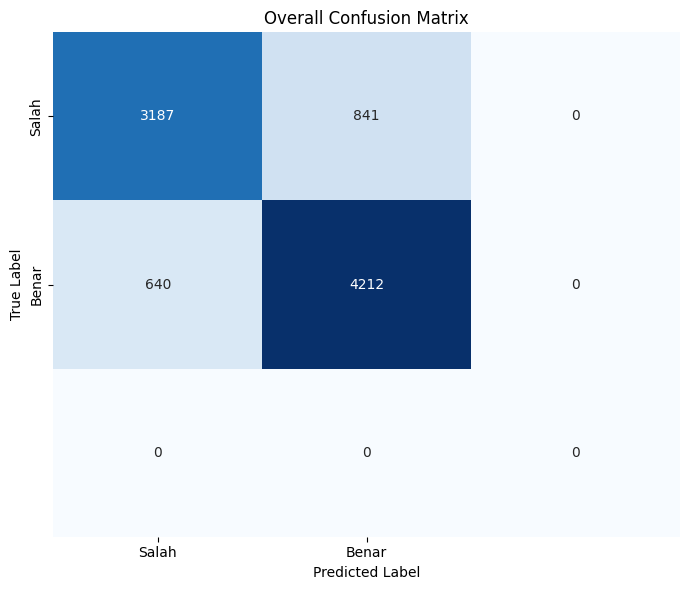

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define class labels for readability
class_labels = ['Salah', 'Benar']

print("\n" + "="*70)
print("📊 OVERALL EVALUATION METRICS (LOPO)")
print("="*70)

# 1. Overall Accuracy
overall_accuracy = accuracy_score(all_y_true, all_y_pred)
print(f"Overall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)\n")

# 2. Overall Classification Report (Precision, Recall, F1-score)
print("Overall Classification Report:")
print(classification_report(all_y_true, all_y_pred, target_names=class_labels))

# 3. Overall Confusion Matrix
overall_cm = confusion_matrix(all_y_true, all_y_pred, labels=[0, 1, 2])

print("\nOverall Confusion Matrix (True vs Predicted):")
print("          Salah   Benar   Berdiri")
print(f"Salah     {overall_cm[0,0]:5d}   {overall_cm[0,1]:5d}   {overall_cm[0,2]:5d}")
print(f"Benar     {overall_cm[1,0]:5d}   {overall_cm[1,1]:5d}   {overall_cm[1,2]:5d}")
print(f"Berdiri   {overall_cm[2,0]:5d}   {overall_cm[2,1]:5d}   {overall_cm[2,2]:5d}")

# 4. Visualize Overall Confusion Matrix
plt.figure(figsize=(7, 6))
sns.heatmap(overall_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Overall Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


📊 VISUALISASI CONFUSION MATRIX PER SUBJECT (HEATMAP)


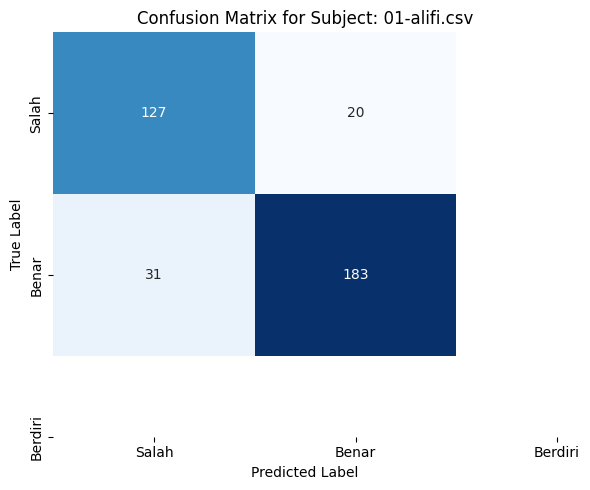

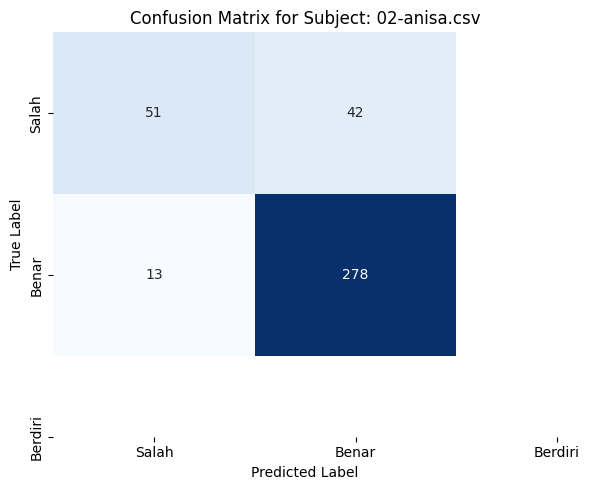

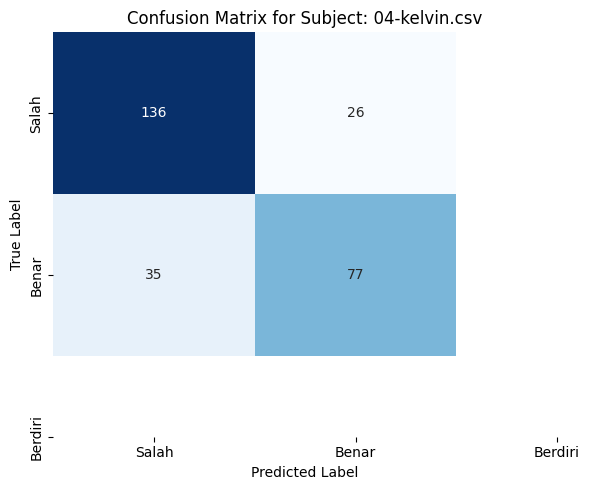

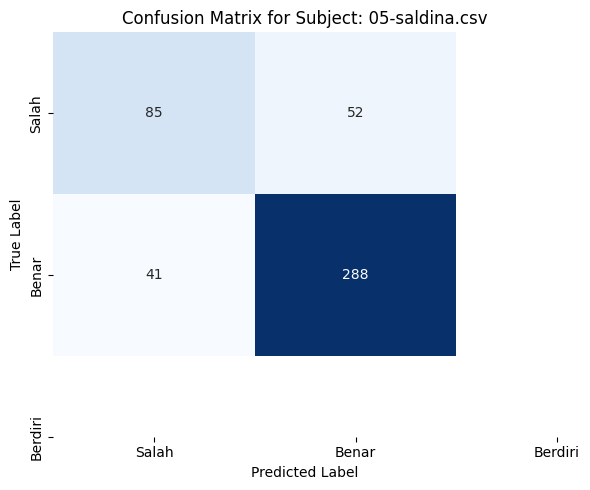

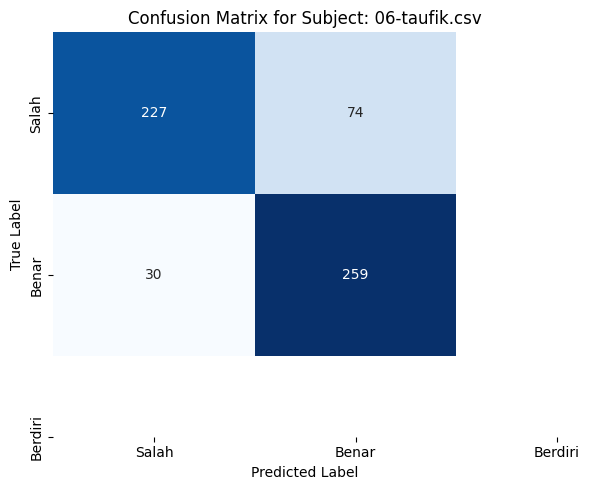

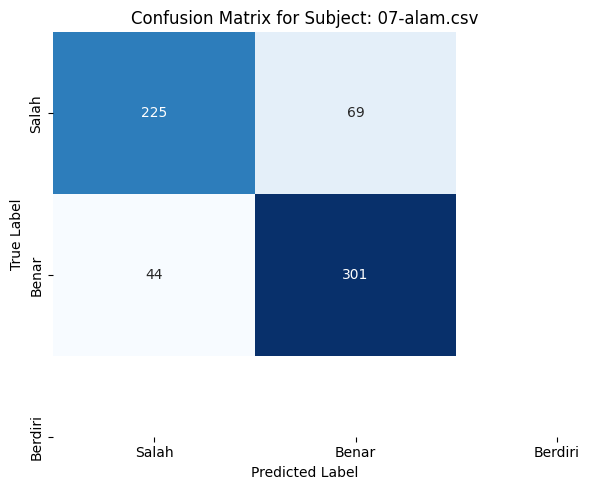

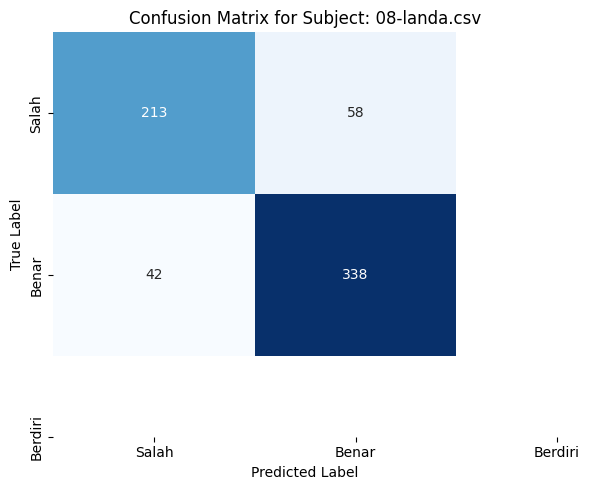

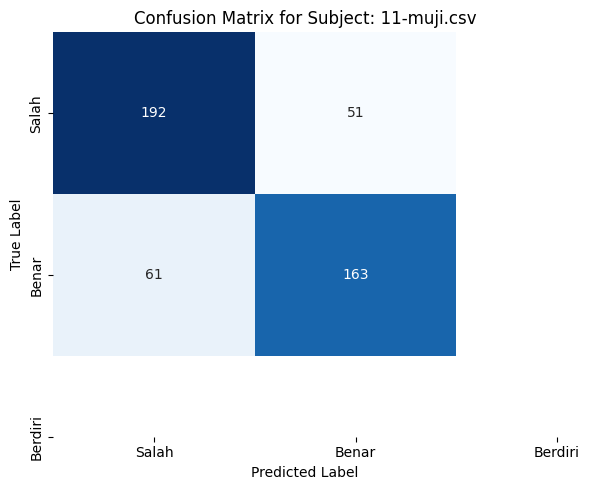

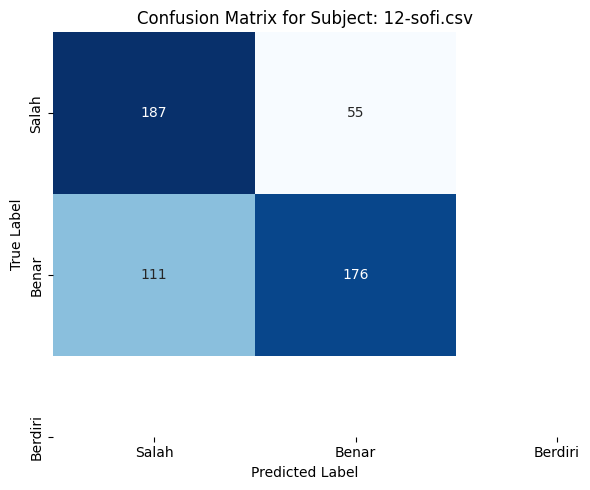

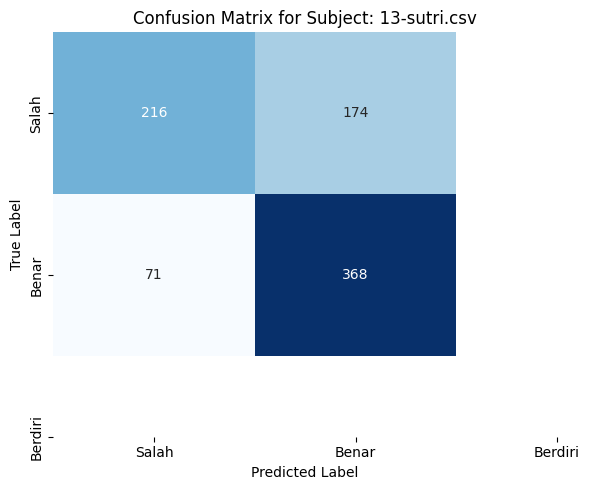

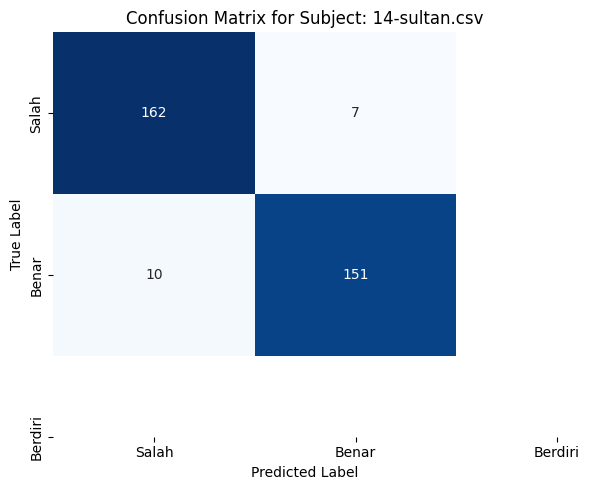

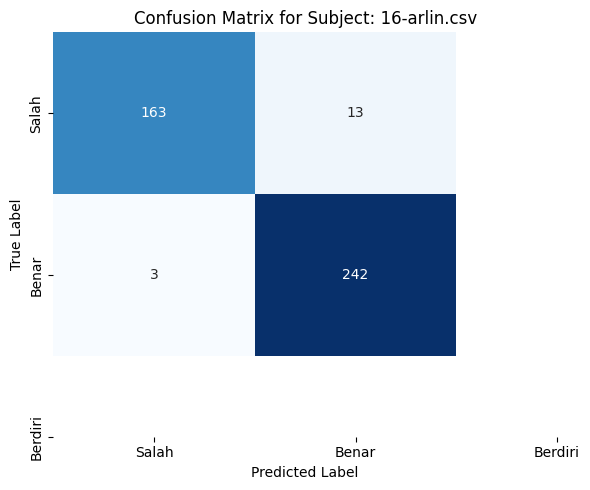

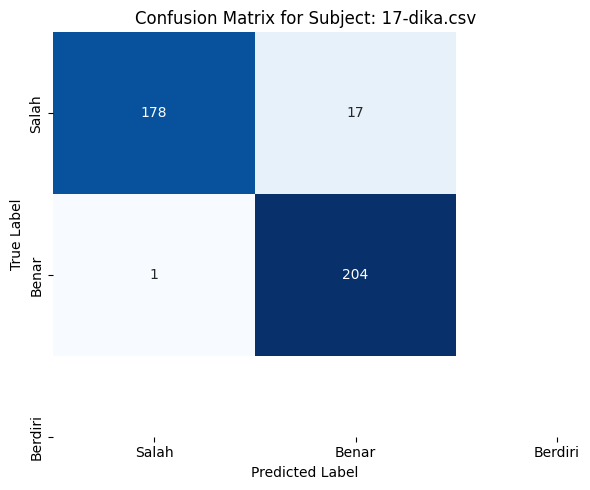

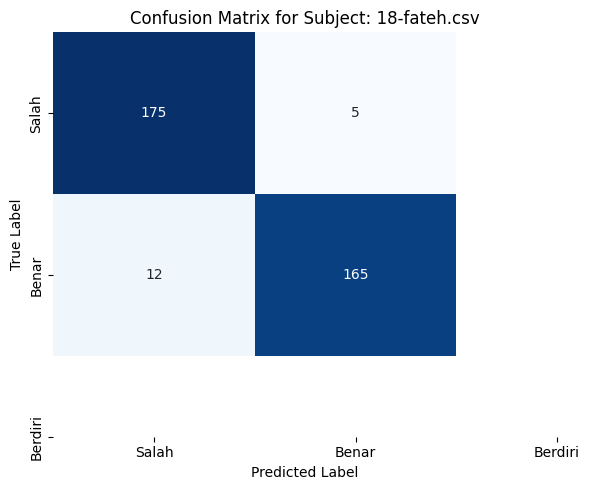

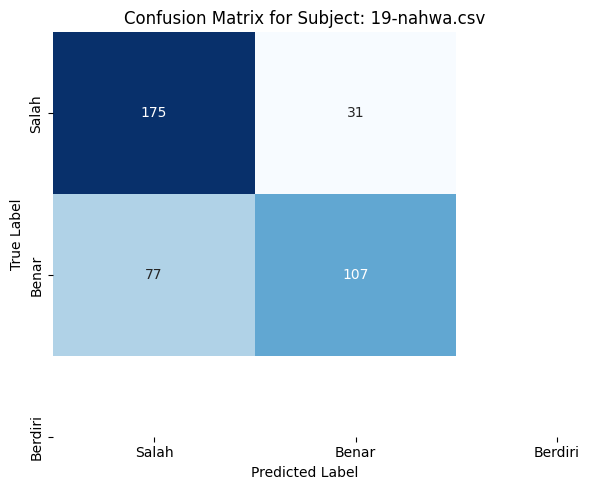

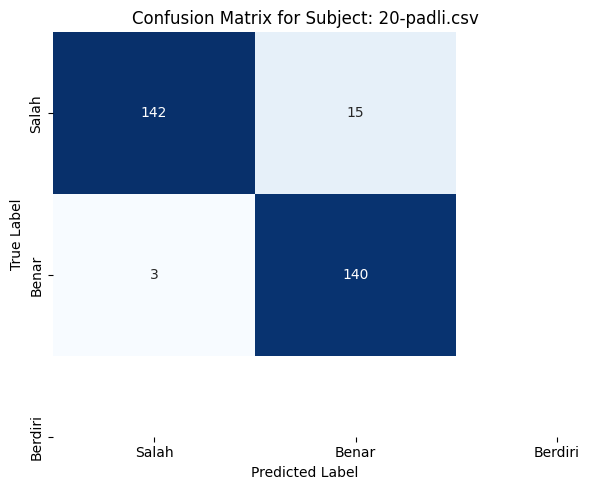

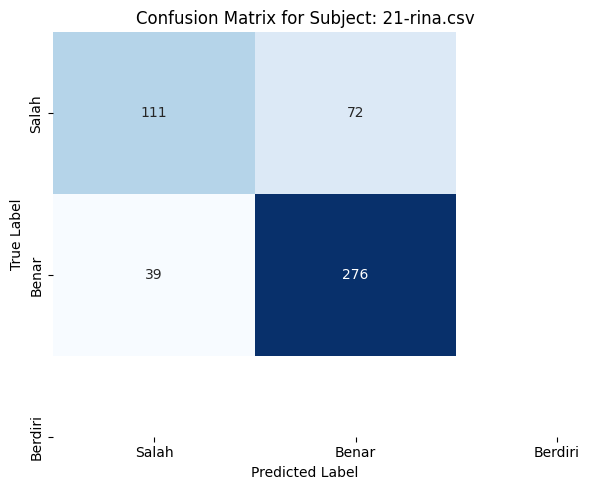

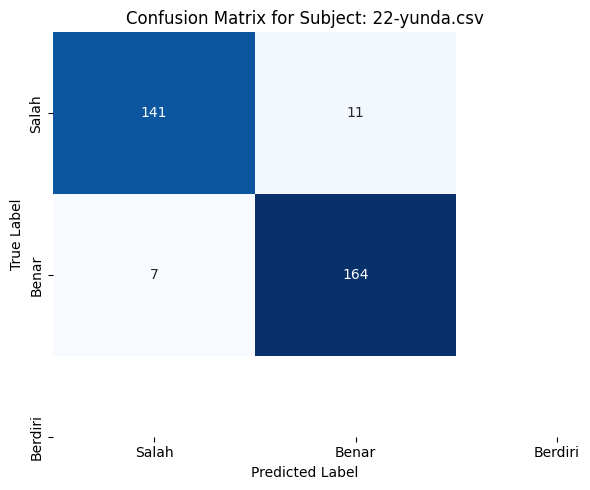

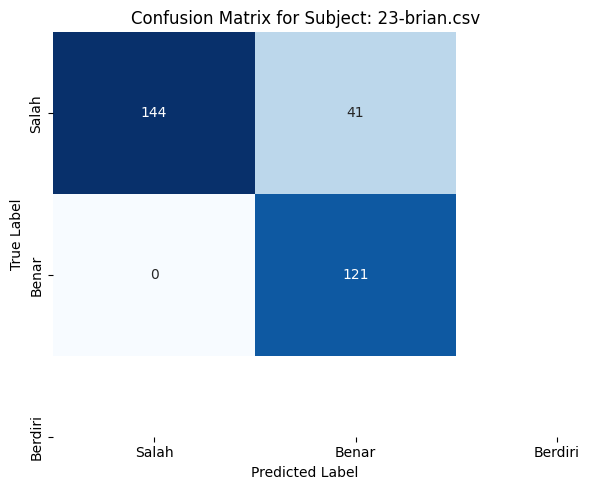

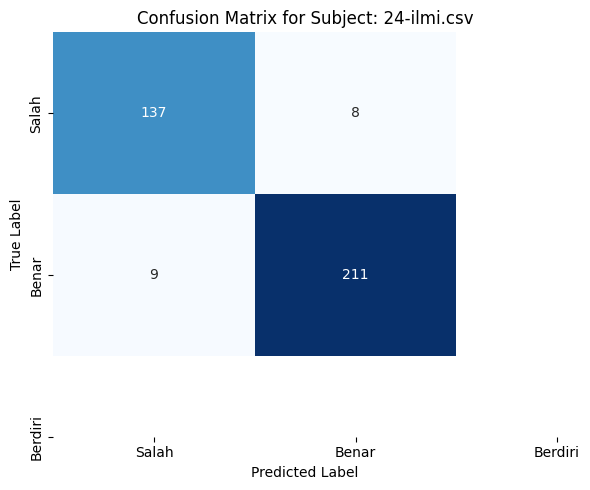

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the class labels
class_labels = ['Salah', 'Benar', 'Berdiri']

print("\n" + "="*70)
print("📊 VISUALISASI CONFUSION MATRIX PER SUBJECT (HEATMAP)")
print("="*70)

# Iterate through each subject's confusion matrix and visualize it
for subject, cm in conf_matrices.items():
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix for Subject: {subject}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()


## Analisis Feature Importance

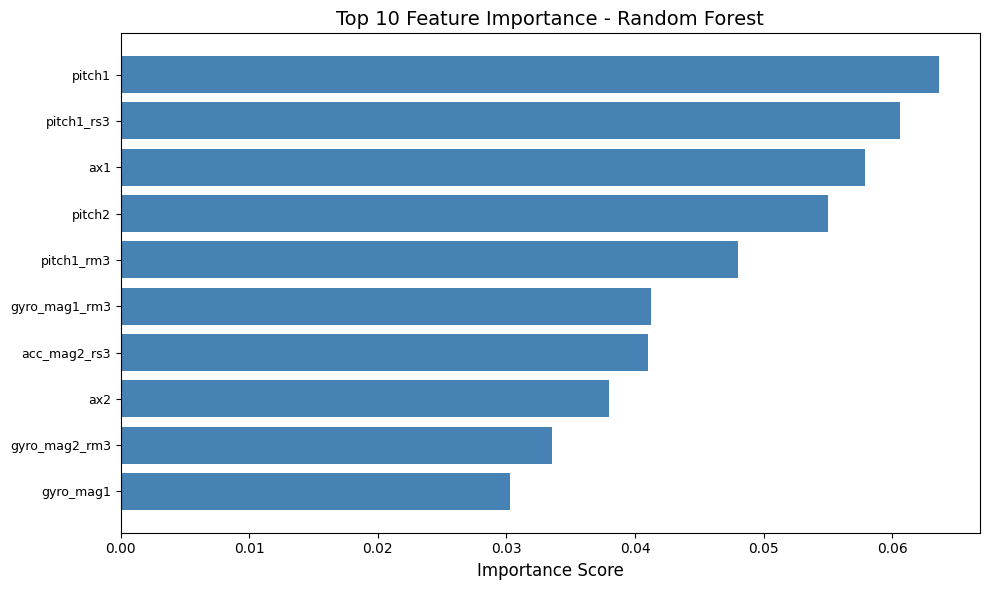


TABEL SELURUH FEATURE IMPORTANCE (diurutkan menurun)
 Rank        Feature Importance
    1         pitch1   0.063648
    2     pitch1_rs3   0.060596
    3            ax1   0.057868
    4         pitch2   0.055000
    5     pitch1_rm3   0.048010
    6  gyro_mag1_rm3   0.041261
    7   acc_mag2_rs3   0.041038
    8            ax2   0.038006
    9  gyro_mag2_rm3   0.033539
   10      gyro_mag1   0.030307
   11            az2   0.029675
   12  gyro_mag1_rs3   0.027154
   13      gyro_mag2   0.024092
   14   acc_mag1_rs3   0.021852
   15     altitude_m   0.021751
   16  gyro_mag2_rs3   0.021057
   17   acc_mag2_rm3   0.020196
   18            gy1   0.019601
   19            az1   0.018192
   20        diff_az   0.017037
   21   acc_mag1_rm3   0.015900
   22       acc_mag1   0.015842
   23        diff_ax   0.015712
   24            gy2   0.015577
   25   pressure_hpa   0.015378
   26       acc_mag2   0.015312
   27 diff_pitch_rm3   0.014219
   28  diff_roll_rm3   0.012998
   29 diff_pitch_r

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Asumsi rf_model dan X_train_win_last_fold sudah ada dari kode LOPO sebelumnya
importances = rf_model.feature_importances_
feature_names = X_train_win_last_fold.columns

# Urutkan berdasarkan importance menurun
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# ============================================
# 1. VISUALISASI 10 FITUR TERTINGGI
# ============================================
top_n = 10
top_features = sorted_features[:top_n]
top_importances = sorted_importances[:top_n]

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), top_importances, align='center', color='steelblue')
plt.yticks(range(top_n), top_features, fontsize=9)
plt.xlabel('Importance Score', fontsize=12)
plt.title(f'Top {top_n} Feature Importance - Random Forest', fontsize=14)
plt.gca().invert_yaxis()  # fitur terpenting di atas
plt.tight_layout()
plt.show()

# ============================================
# 2. TABEL UNTUK SISANYA (semua fitur + 10 tertinggi juga bisa ditampilkan)
#    Opsi A: Tabel semua fitur (lengkap)
#    Opsi B: Tabel hanya fitur ke-11 sampai akhir
# ============================================

# Opsi A: Tabel semua fitur (direkomendasikan agar tidak kehilangan informasi)
print("\n" + "="*60)
print("TABEL SELURUH FEATURE IMPORTANCE (diurutkan menurun)")
print("="*60)
importance_df = pd.DataFrame({
    'Rank': range(1, len(sorted_features)+1),
    'Feature': sorted_features,
    'Importance': sorted_importances
})
# Format Importance dengan 6 desimal
importance_df['Importance'] = importance_df['Importance'].apply(lambda x: f"{x:.6f}")
print(importance_df.to_string(index=False))

# Atau jika hanya ingin sisanya (fitur ke-11 s/d akhir):
# print("\n" + "="*60)
# print("TABEL SISA FITUR (selain 10 tertinggi)")
# print("="*60)
# remaining_df = importance_df.iloc[top_n:].reset_index(drop=True)
# print(remaining_df.to_string(index=False))

## Analisis

In [32]:
import pandas as pd

# === CEK 1: Hasil LOPO per fold ===
results_df = pd.DataFrame(lopo_results)
print(results_df.to_string(index=False))
print(f"\nRata-rata: {results_df['accuracy'].mean():.4f}")
print(f"Std Dev  : {results_df['accuracy'].std():.4f}")

# === CEK 2: Classification report per kelas ===
from sklearn.metrics import classification_report
print("\n", classification_report(
    all_y_true, all_y_pred,
    target_names=['Salah', 'Benar'] # 'Berdiri' dihapus karena filter windowing
))

# === CEK 3: Frekuensi sampling ===
print(f"\nsampling_freq = {sampling_freq:.4f} Hz")

# === CEK 4: Distribusi kelas per subjek ===
print("\nDistribusi label per subjek:")
print(df_clean.groupby(['source_file','label'])['label'].count().unstack(fill_value=0))

# === CEK 5: Jumlah windows per subjek ===
print("\nJumlah windows per subjek (test):")
for r in lopo_results:
    print(f"  {r['test_subject']:<30s}: {r['n_test_samples']:>4d} samples")

 fold   test_subject  n_train_samples  n_test_samples  accuracy
    1   01-alifi.csv             8519             361  0.858726
    2   02-anisa.csv             8496             384  0.856771
    3  04-kelvin.csv             8606             274  0.777372
    4 05-saldina.csv             8414             466  0.800429
    5  06-taufik.csv             8290             590  0.823729
    6    07-alam.csv             8241             639  0.823161
    7   08-landa.csv             8229             651  0.846390
    8    11-muji.csv             8413             467  0.760171
    9    12-sofi.csv             8351             529  0.686200
   10   13-sutri.csv             8051             829  0.704463
   11  14-sultan.csv             8550             330  0.948485
   12   16-arlin.csv             8459             421  0.961995
   13    17-dika.csv             8480             400  0.955000
   14   18-fateh.csv             8523             357  0.952381
   15   19-nahwa.csv             8490   

## Simpan Model dan Output

In [33]:
# Cell Model 6: Simpan model, scaler, hasil evaluasi, dan info penggunaan model
import joblib
import json
import os

# ========== ATUR PATH PENYIMPANAN DI SINI ==========
SAVE_DIR = '/content/drive/MyDrive/Dataset Skripsi /OutputColab'
# ==================================================

# Buat folder jika belum ada
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================
# Simpan model dan scaler
# ==========================
joblib.dump(
    rf_model,
    os.path.join(
        SAVE_DIR,
        'random_forest_model.pkl'
    )
)

joblib.dump(
    scaler,
    os.path.join(
        SAVE_DIR,
        'scaler.pkl'
    )
)

print(
    f"Model dan scaler disimpan di: {SAVE_DIR}"
)

# ==========================
# Simpan classification report
# ==========================
report = classification_report(
    all_y_true,
    all_y_pred,
    target_names=[
        'Salah (0)',
        'Benar (1)'
    ], # Removed 'Berdiri (2)' as it's filtered during windowing
    output_dict=True
)

with open(
    os.path.join(
        SAVE_DIR,
        'classification_report.json'
    ),
    'w'
) as f:
    json.dump(
        report,
        f,
        indent=4
    )

print(
    f"Classification report disimpan ke: "
    f"{SAVE_DIR}/classification_report.json"
)

# ==========================
# Simpan prediksi ke CSV
# ==========================
# The X_test_scaled, y_test, and y_pred variables from the LAST fold are currently used here.
# To save *all* predictions from the LOPO process, we should re-construct a DataFrame from all_y_true and all_y_pred.
# However, X_test_scaled only contains features from the last fold's test set.
# A more comprehensive way would be to collect all X_test_scaled for each fold along with their y_true and y_pred.
# For now, let's assume the user wants the prediction and true labels from the *overall* LOPO evaluation.

# Create a DataFrame for overall predictions, aligning with the all_y_true and all_y_pred
# Note: This will not include the features (X_test_scaled) for all predictions unless they are also collected.
# If the user wishes to save X_test_scaled for *all* folds, that data would need to be accumulated during the LOPO loop.
# For simplicity, we create a DataFrame with just true and predicted labels for the overall aggregated results.

overall_predictions_df = pd.DataFrame({
    'true_label': all_y_true,
    'predicted_label': all_y_pred
})

overall_predictions_df.to_csv(
    os.path.join(
        SAVE_DIR,
        'overall_predictions.csv'
    ),
    index=False
)

print(
    f"Overall prediksi disimpan ke: "
    f"{SAVE_DIR}/overall_predictions.csv"
)

# ==========================
# Simpan informasi model ke TXT
# ==========================

info_model = f"""
INFORMASI MODEL RANDOM FOREST
=============================

Nama Model:
random_forest_model.pkl

Scaler:
scaler.pkl

Jenis Model:
Random Forest Classifier

INPUT YANG DIPERLUKAN
---------------------
PENTING: Data harus melalui add_derived_features() dan add_rolling_features()
sebelum dimasukkan ke model.

Fitur setelah rekayasa:
{list(X_train_win_last_fold.columns)}

Jumlah fitur: {len(X_train_win_last_fold.columns)}


Catatan:
- Urutan input HARUS sama seperti daftar fitur di atas
- Data input harus melalui proses scaling
  menggunakan scaler.pkl sebelum prediksi
- Format input disarankan:
  DataFrame pandas atau array numerik

CONTOH ALUR PENGGUNAAN
---------------------

1. Load model:
   rf_model = joblib.load(
       'random_forest_model.pkl'
   )

2. Load scaler:
   scaler = joblib.load(
       'scaler.pkl'
   )

3. Masukkan data baru

4. Lakukan scaling:
   data_scaled = scaler.transform(
       data_baru
   )

5. Prediksi:
   hasil = rf_model.predict(
       data_scaled
   )

OUTPUT YANG DIHASILKAN
----------------------

0 = Salah
1 = Benar

Interpretasi:
- Output model berupa kelas numerik
- Gunakan mapping di atas
  untuk membaca hasil prediksi

File dibuat otomatis setelah training.
"""

with open(
    os.path.join(
        SAVE_DIR,
        'model_info.txt'
    ),
    'w',
    encoding='utf-8'
) as f:
    f.write(info_model)

print(
    f"Informasi model disimpan ke: "
    f"{SAVE_DIR}/model_info.txt"
)
with open(os.path.join(SAVE_DIR, 'feature_names.json'), 'w') as f:
    json.dump(list(X_train_win_last_fold.columns), f)

Model dan scaler disimpan di: /content/drive/MyDrive/Dataset Skripsi /OutputColab
Classification report disimpan ke: /content/drive/MyDrive/Dataset Skripsi /OutputColab/classification_report.json
Overall prediksi disimpan ke: /content/drive/MyDrive/Dataset Skripsi /OutputColab/overall_predictions.csv
Informasi model disimpan ke: /content/drive/MyDrive/Dataset Skripsi /OutputColab/model_info.txt


# Hyperparameter

In [ ]:
# ====================================================
# HYPERPARAMETER TUNING HANYA PADA SUBJEK DENGAN AKURASI TERENDAH
# ====================================================

from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd

LABEL_BERDIRI = 2

# --- 1. Filter data mentah (tanpa feature engineering) ---
mask_non_berdiri = y != LABEL_BERDIRI
X_raw_filtered = X[mask_non_berdiri].reset_index(drop=True)
y_raw_filtered = y[mask_non_berdiri].reset_index(drop=True)
groups_raw_filtered = groups[mask_non_berdiri]

# --- 2. Daftar subjek unik ---
subjek_unik = np.unique(groups_raw_filtered)
print(f"Subjek unik: {subjek_unik}")

# Tentukan subjek dengan akurasi terendah (dari output LOPO sebelumnya)
worst_subject = "12-sofi.csv"  # Sesuaikan dengan nama persis di groups_raw_filtered

# --- 3. Fungsi untuk feature engineering per subjek (sama seperti di loop LOPO) ---
def process_subject_data(X_sub, y_sub, subject_name):
    """
    Terapkan derived features dan rolling features untuk satu subjek.
    Mengembalikan X, y yang sudah diproses (tanpa NaN/inf).
    """
    X_sub = add_derived_features(X_sub)
    # Rolling features per subjek (n=3, seperti kode LOPO)
    groups_sub = np.array([subject_name] * len(X_sub))
    X_rolled, y_rolled = add_rolling_per_subject(X_sub, y_sub, groups_sub, n=3)
    # Bersihkan nilai inf/NaN
    X_rolled = X_rolled.replace([np.inf, -np.inf], 0).fillna(0)
    return X_rolled, y_rolled

# --- 4. Pisahkan data untuk training (semua subjek kecuali worst) dan validation (worst) ---
print("\nMemproses feature engineering untuk training set (semua subjek kecuali worst)...")
X_train_list = []
y_train_list = []

for subj in subjek_unik:
    if subj == worst_subject:
        continue
    mask = groups_raw_filtered == subj
    X_sub_raw = X_raw_filtered[mask].reset_index(drop=True)
    y_sub_raw = y_raw_filtered[mask].reset_index(drop=True)
    X_proc, y_proc = process_subject_data(X_sub_raw, y_sub_raw, subj)
    X_train_list.append(X_proc)
    y_train_list.append(y_proc)

X_train = pd.concat(X_train_list, ignore_index=True)
y_train = pd.concat(y_train_list, ignore_index=True)
print(f"Train set size: {X_train.shape}")

print(f"\nMemproses feature engineering untuk validation set (subjek terendah: {worst_subject})...")
mask_worst = groups_raw_filtered == worst_subject
X_worst_raw = X_raw_filtered[mask_worst].reset_index(drop=True)
y_worst_raw = y_raw_filtered[mask_worst].reset_index(drop=True)
X_val, y_val = process_subject_data(X_worst_raw, y_worst_raw, worst_subject)
print(f"Validation set size: {X_val.shape}")

# --- 5. Gabungkan untuk GridSearch ---
X_combined = pd.concat([X_train, X_val], ignore_index=True)
y_combined = pd.concat([y_train, y_val], ignore_index=True)

# PredefinedSplit: -1 = train, 0 = validation
test_fold = np.concatenate([-np.ones(len(X_train)), np.zeros(len(X_val))])
ps = PredefinedSplit(test_fold)

# --- 6. Pipeline dan parameter grid ---
pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    'rf__n_estimators': [100, 150, 200],
    'rf__max_depth': [None, 20, 30],
    'rf__min_samples_split': [5, 6, 7],
    'rf__min_samples_leaf': [1],
    'rf__max_features': ['sqrt', 0.5, 0.6],
    'rf__bootstrap': [False],
    'rf__class_weight': ['balanced'],
    'rf__criterion': ['entropy']
}

# --- 7. Jalankan tuning ---
print("\nMenjalankan hyperparameter tuning pada validasi subjek terendah...")
grid_search = GridSearchCV(
    pipeline, param_grid, cv=ps, scoring='f1_weighted', n_jobs=-1, verbose=1
)
grid_search.fit(X_combined, y_combined)

best_params = grid_search.best_params_
print("\n" + "="*50)
print("HYPERPARAMETER TERBAIK:")
print(best_params)
print(f"F1-weighted pada validation set: {grid_search.best_score_:.4f}")
print("="*50)

# --- 8. Ekstrak parameter untuk RandomForest ---
rf_best_params = {k.replace('rf__', ''): v for k, v in best_params.items()}
rf_best_params['random_state'] = 42
rf_best_params['n_jobs'] = -1

# --- 9. LOPO dengan parameter terbaik pada semua subjek ---
print("\n" + "="*50)
print("MENJALANKAN LOPO DENGAN PARAMETER TERBAIK PADA SEMUA SUBJEK")
print("="*50)

lopo_results_best = []

for fold_idx, test_subject in enumerate(subjek_unik):
    # Filter data mentah untuk subjek uji
    test_mask = groups_raw_filtered == test_subject
    train_mask = groups_raw_filtered != test_subject

    X_test_raw = X_raw_filtered[test_mask].reset_index(drop=True)
    y_test_raw = y_raw_filtered[test_mask].reset_index(drop=True)

    # Proses feature engineering untuk training (gabungan semua subjek lain)
    X_train_list = []
    y_train_list = []
    for subj in subjek_unik:
        if subj == test_subject:
            continue
        mask = groups_raw_filtered == subj
        X_sub = X_raw_filtered[mask].reset_index(drop=True)
        y_sub = y_raw_filtered[mask].reset_index(drop=True)
        X_proc, y_proc = process_subject_data(X_sub, y_sub, subj)
        X_train_list.append(X_proc)
        y_train_list.append(y_proc)
    X_train = pd.concat(X_train_list, ignore_index=True)
    y_train = pd.concat(y_train_list, ignore_index=True)

    # Proses feature engineering untuk testing (hanya subjek uji)
    X_test, y_test = process_subject_data(X_test_raw, y_test_raw, test_subject)

    # Scaling
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Training dengan parameter terbaik
    model = RandomForestClassifier(**rf_best_params)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    lopo_results_best.append({
        'fold': fold_idx + 1,
        'test_subject': test_subject,
        'accuracy': acc
    })
    print(f"Fold {fold_idx+1:2d} | Test: {test_subject:<30s} | Acc: {acc:.4f} ({acc*100:.1f}%)")

# --- 10. Ringkasan hasil ---
print("\n" + "="*50)
print("RINGKASAN HASIL LOPO DENGAN PARAMETER TERBAIK")
print("="*50)
accuracies = [res['accuracy'] for res in lopo_results_best]
print(f"Rata-rata akurasi: {np.mean(accuracies):.4f}")
print(f"Std akurasi: {np.std(accuracies):.4f}")
print(f"Minimum akurasi: {np.min(accuracies):.4f}")
print(f"Maksimum akurasi: {np.max(accuracies):.4f}")

Subjek unik: ['01-alifi.csv' '02-anisa.csv' '04-kelvin.csv' '05-saldina.csv'
 '06-taufik.csv' '07-alam.csv' '08-landa.csv' '11-muji.csv' '12-sofi.csv'
 '13-sutri.csv' '14-sultan.csv' '16-arlin.csv' '17-dika.csv'
 '18-fateh.csv' '19-nahwa.csv' '20-padli.csv' '21-rina.csv' '22-yunda.csv'
 '23-brian.csv' '24-ilmi.csv']

Memproses feature engineering untuk training set (semua subjek kecuali worst)...
Train set size: (8351, 46)

Memproses feature engineering untuk validation set (subjek terendah: 12-sofi.csv)...
Validation set size: (529, 46)

Menjalankan hyperparameter tuning pada validasi subjek terendah...
Fitting 1 folds for each of 81 candidates, totalling 81 fits

HYPERPARAMETER TERBAIK:
{'rf__bootstrap': False, 'rf__class_weight': 'balanced', 'rf__criterion': 'entropy', 'rf__max_depth': 30, 'rf__max_features': 0.6, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 7, 'rf__n_estimators': 100}
F1-weighted pada validation set: 0.7447

MENJALANKAN LOPO DENGAN PARAMETER TERBAIK PADA SEM

In [ ]:
import os
import json
import pandas as pd

# Ensure SAVE_DIR is defined from previous cells
if 'SAVE_DIR' not in globals():
    SAVE_DIR = '/content/drive/MyDrive/Dataset Skripsi /OutputColab'
os.makedirs(SAVE_DIR, exist_ok=True)

print("\n" + "="*50)
print("SAVING HYPERPARAMETER TUNING RESULTS")
print("="*50)

# Save best parameters
best_params_path = os.path.join(SAVE_DIR, 'best_hyperparameters.json')
with open(best_params_path, 'w') as f:
    json.dump(grid_search.best_params_, f, indent=4)
print(f"Best hyperparameters saved to: {best_params_path}")

# Save best score
best_score_path = os.path.join(SAVE_DIR, 'best_score.txt')
with open(best_score_path, 'w') as f:
    f.write(f"Best Score (f1_weighted): {grid_search.best_score_:.4f}\n")
print(f"Best score saved to: {best_score_path}")

# Save all CV results to CSV
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_path = os.path.join(SAVE_DIR, 'hyperparameter_cv_results.csv')
cv_results_df.to_csv(cv_results_path, index=False)
print(f"All CV results saved to: {cv_results_path}")

print("\n--- Hyperparameter Tuning Summary ---")
print(f"Best F1-Weighted Score: {grid_search.best_score_:.4f}")
print("Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
